In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import pandas as pd
import re
import rasterio
import random
from rasterio.transform import from_origin
from pyproj import Transformer
import re
import scipy as sp
import pyreadr
import sys
sys.path.append(os.path.abspath('../src/'))
from utils import *
from scipy import stats
import argparse
import copy
import glob
import argparse
import cProfile
import csv
from functools import partial
import itertools
import math
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import os
import rasterio
from scipy import stats
from scipy.optimize import minimize
# from scipy.special import binom
from skimage import graph
import sys
import time
from tqdm import tqdm
import numpy.ma as ma
import warnings
import numpy as np
import psutil
import gc

warnings.filterwarnings("ignore")

import logging
logging.getLogger("distributed").setLevel(logging.ERROR)


Bad key "text.kerning_factor" on line 4 in
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


### Random Grid Generations

In [23]:
import pandas as pd
import random
import os

# ==== FILE PATHS ====
grid_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/1000m_trap_grid.csv"
remove_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/traps_to_remove_1km.csv"
output_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_1km"

# ==== LOAD DATA ====
grid_df = pd.read_csv(grid_file)
remove_df = pd.read_csv(remove_file)

# Columns
trap_id_col = "Trap_index"   # ID column used for selection
trap_index_col = "Trap_index"  # Column to output in excluded files

# ==== REMOVE BLACKLISTED TRAPS ====
filtered_df = grid_df[~grid_df[trap_id_col].isin(remove_df[trap_id_col])]

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# ==== RANDOM SELECTIONS ====
trap_counts = range(10, 81, 10)

for trap_count in trap_counts:
    for run_id in range(1, 11):
        # Select traps
        selected_df = filtered_df.sample(
            n=trap_count, replace=False,
            random_state=random.randint(0, 1_000_000)
        )

        # Save selected traps (original format)
        selected_filename = f"{trap_count}traps_{run_id}.txt"
        selected_path = os.path.join(output_dir, selected_filename)
        selected_df.to_csv(selected_path, index=False)

        # Excluded traps — only trap_index column
        excluded_df = grid_df[~grid_df[trap_id_col].isin(selected_df[trap_id_col])]

        excluded_only_index = excluded_df[[trap_index_col]]

        excluded_filename = f"{trap_count}traps_{run_id}_excluded.txt"
        excluded_path = os.path.join(output_dir, excluded_filename)
        excluded_only_index.to_csv(excluded_path, index=False, header=False)

        print(f"Saved: {selected_filename} | {excluded_filename}")

print("✅ All trap and excluded trap-index files generated successfully.")


Saved: 10traps_1.txt | 10traps_1_excluded.txt
Saved: 10traps_2.txt | 10traps_2_excluded.txt
Saved: 10traps_3.txt | 10traps_3_excluded.txt
Saved: 10traps_4.txt | 10traps_4_excluded.txt
Saved: 10traps_5.txt | 10traps_5_excluded.txt
Saved: 10traps_6.txt | 10traps_6_excluded.txt
Saved: 10traps_7.txt | 10traps_7_excluded.txt
Saved: 10traps_8.txt | 10traps_8_excluded.txt
Saved: 10traps_9.txt | 10traps_9_excluded.txt
Saved: 10traps_10.txt | 10traps_10_excluded.txt
Saved: 20traps_1.txt | 20traps_1_excluded.txt
Saved: 20traps_2.txt | 20traps_2_excluded.txt
Saved: 20traps_3.txt | 20traps_3_excluded.txt
Saved: 20traps_4.txt | 20traps_4_excluded.txt
Saved: 20traps_5.txt | 20traps_5_excluded.txt
Saved: 20traps_6.txt | 20traps_6_excluded.txt
Saved: 20traps_7.txt | 20traps_7_excluded.txt
Saved: 20traps_8.txt | 20traps_8_excluded.txt
Saved: 20traps_9.txt | 20traps_9_excluded.txt
Saved: 20traps_10.txt | 20traps_10_excluded.txt
Saved: 30traps_1.txt | 30traps_1_excluded.txt
Saved: 30traps_2.txt | 30traps

In [24]:
import pandas as pd
import random
import os

# ==== FILE PATHS ====
grid_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_500m/500m_trap_grid.csv"
remove_file = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_500m/traps_to_remove_UTM10N_updated.csv"
output_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Random/full_grid_500m"

# ==== LOAD DATA ====
grid_df = pd.read_csv(grid_file)
remove_df = pd.read_csv(remove_file)

# Columns
trap_id_col = "Trap_index"    # Used for filtering & selection

# ==== REMOVE BLACKLISTED TRAPS ====
filtered_df = grid_df[~grid_df[trap_id_col].isin(remove_df[trap_id_col])]

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# ==== RANDOM SELECTIONS ====
trap_counts = range(10, 81, 10)

for trap_count in trap_counts:
    for run_id in range(1, 11):
        # Select traps (random sample)
        selected_df = filtered_df.sample(
            n=trap_count, replace=False,
            random_state=random.randint(0, 1_000_000)
        )

        # Keep only the Trap_index column for selected traps
        selected_only_index = selected_df[[trap_id_col]]

        # Save selected traps as .txt (one per line, no header)
        selected_filename = f"{trap_count}traps_{run_id}.txt"
        selected_path = os.path.join(output_dir, selected_filename)
        selected_only_index.to_csv(selected_path, index=False, header=False)

        # Excluded traps — from original grid_df
        excluded_df = grid_df[~grid_df[trap_id_col].isin(selected_df[trap_id_col])]
        excluded_only_index = excluded_df[[trap_id_col]]

        # Save excluded traps as .txt
        excluded_filename = f"{trap_count}traps_{run_id}_excluded.txt"
        excluded_path = os.path.join(output_dir, excluded_filename)
        excluded_only_index.to_csv(excluded_path, index=False, header=False)

        print(f"Saved: {selected_filename} | {excluded_filename}")

print("✅ All trap ID .txt files (selected & excluded) generated successfully.")


Saved: 10traps_1.txt | 10traps_1_excluded.txt
Saved: 10traps_2.txt | 10traps_2_excluded.txt
Saved: 10traps_3.txt | 10traps_3_excluded.txt
Saved: 10traps_4.txt | 10traps_4_excluded.txt
Saved: 10traps_5.txt | 10traps_5_excluded.txt
Saved: 10traps_6.txt | 10traps_6_excluded.txt
Saved: 10traps_7.txt | 10traps_7_excluded.txt
Saved: 10traps_8.txt | 10traps_8_excluded.txt
Saved: 10traps_9.txt | 10traps_9_excluded.txt
Saved: 10traps_10.txt | 10traps_10_excluded.txt
Saved: 20traps_1.txt | 20traps_1_excluded.txt
Saved: 20traps_2.txt | 20traps_2_excluded.txt
Saved: 20traps_3.txt | 20traps_3_excluded.txt
Saved: 20traps_4.txt | 20traps_4_excluded.txt
Saved: 20traps_5.txt | 20traps_5_excluded.txt
Saved: 20traps_6.txt | 20traps_6_excluded.txt
Saved: 20traps_7.txt | 20traps_7_excluded.txt
Saved: 20traps_8.txt | 20traps_8_excluded.txt
Saved: 20traps_9.txt | 20traps_9_excluded.txt
Saved: 20traps_10.txt | 20traps_10_excluded.txt
Saved: 30traps_1.txt | 30traps_1_excluded.txt
Saved: 30traps_2.txt | 30traps

In [25]:
grid_df

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


### Forward Greedy SECR File Generation

In [26]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG36/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG36/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:70]  # Limit to first 70 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG36/selected_traps.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('full_grid_500m/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG36/FG36-excluded_traps-70.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 70 traps
Excluded 2367 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


### Selected Traps Heat Map

In [27]:
parent_dir = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Forward Greedy'
folders = [f'FG{i}' for i in range(48, 54)]

all_data = []
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        all_data.append(df)
df_all = pd.concat(all_data, ignore_index=True)

# Count how many times each Trap_index was selected
trap_counts = df_all['Trap_index'].value_counts().reset_index()
trap_counts.columns = ['Trap_index', 'count']

# Load candidate traps (includes x, y, Prior_cam, Trap_index)
candidate_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv'
df_candidates = pd.read_csv(candidate_path)

# Ensure Trap_index columns are numeric and clean
df_candidates['Trap_index'] = pd.to_numeric(df_candidates['Trap_index'], errors='coerce')
trap_counts['Trap_index'] = pd.to_numeric(trap_counts['Trap_index'], errors='coerce')

df_candidates = df_candidates.dropna(subset=['Trap_index']).copy()
trap_counts = trap_counts.dropna(subset=['Trap_index']).copy()

df_candidates['Trap_index'] = df_candidates['Trap_index'].astype(int)
trap_counts['Trap_index'] = trap_counts['Trap_index'].astype(int)

# Merge candidate data (with x, y, Prior_cam) and counts on Trap_index
result = pd.merge(df_candidates, trap_counts, on='Trap_index', how='right')

# Select desired columns: coordinates come from candidates file now
result = result[['Trap_index', 'x', 'y', 'Prior_cam', 'count']]

# Save result or print preview
result.to_csv('trap_id_selection_count.csv', index=False)

result2 =result[result['Prior_cam'] == 0]
result2.to_csv('trap_id_selection_count_NEW_CAMS.csv', index=False)

In [28]:
result2

,Trap_index,x,y,Prior_cam,count
21,1041,493483.355444,5.651120e+06,0,5
22,717,521860.089284,5.640515e+06,0,5
23,128,517949.862830,5.658720e+06,0,5
24,1038,491343.699278,5.652666e+06,0,5
25,897,493720.995156,5.640971e+06,0,5
26,1382,489361.621824,5.654703e+06,0,5
76,1151,492082.054012,5.660346e+06,0,4
77,974,494935.326961,5.663344e+06,0,4
78,1189,493761.232891,5.662357e+06,0,4
79,906,495622.062750,5.642457e+06,0,3


In [29]:
# how many unique proposed layouts of traps are there? essentially, determine the unique combinations of Trap_index that appear in each of the selected_traps.csv files

# for each selected_traps.csv file, return the selected trap indices as a set, then convert the list of sets to a set of frozensets to get unique combinations
unique_combinations = set()
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        unique_combinations.add(frozenset(df['Trap_index'].unique()))
# Count the number of unique combinations
num_unique_combinations = len(unique_combinations)
print(f'Number of unique trap combinations: {num_unique_combinations}')
# # Print the unique combinations
# print(f'Unique trap combinations: {unique_combinations}')


# let me know the folder names that have each of the unique combinations
combination_to_folders = {comb: [] for comb in unique_combinations}
for folder in folders:
    csv_path = os.path.join(parent_dir, folder, 'selected_traps.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, header=None, names=['x', 'y', 'Trap_index'])
        comb = frozenset(df['Trap_index'].unique())
        combination_to_folders[comb].append(folder)
# Print the folder names for each unique combination
for comb, folder_list in combination_to_folders.items():
    print(f'Combination: {comb}, Folders: {folder_list}')
# Save the unique combinations and their corresponding folders to a CSV fil


Number of unique trap combinations: 3
Combination: frozenset({'1409', '1041', '1398', '1436', '1456', '1461', '1416', '1444', '1462', 'Trap_index', '1450', '1422', '906', '1400', '1402', '1413', '1428', '1406', '1421', '1453', '1407', '1434', '1430', '1449', '1455', '1448', '1439', '1427', '1382', '1397', '1463', '1425', '1460', '1189', '1151', '1396', '1414', '1404', '1437', '1438', '1415', '1405', '1408', '1451', '1403', '1418', '1423', '1419', '128', '1429', '1465', '1424', '1411', '1038', '1401', '1412', '717', '1443', '1432', '1445', '1452', '897', '1442', '1420', '1399', '974', '1458', '1426', '1464', '1431', '1440', '1417', '1457', '1410', '1441', '1446', '1459', '1435', '1454', '1433', '1447'}), Folders: ['FG50', 'FG52']
Combination: frozenset({'1409', '1041', '1398', '1436', '1456', '1461', '1416', '1444', '1462', 'Trap_index', '1450', '1422', '906', '1400', '1402', '1413', '1428', '1406', '67', '1421', '1453', '1407', '1434', '1430', '1449', '1455', '1448', '1439', '1427', '1

In [30]:
df = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/Sensor Opt Experiments - Field Combo.csv')
# Exclude nulls and values > 1000
df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 100]

plt.figure(figsize=(10, 6))
sns.violinplot(x='Configuration', y='Absolute Error N', data=df_filtered, inner='box')
plt.yscale('log')  # Apply logarithmic scaling to y axis
plt.title('Violin Plot of Absolute Error N by Configuration (Log Scale)')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N (log scale)')
plt.tight_layout()
plt.show()



NameError: name 'sns' is not defined

<Figure size 720x432 with 0 Axes>

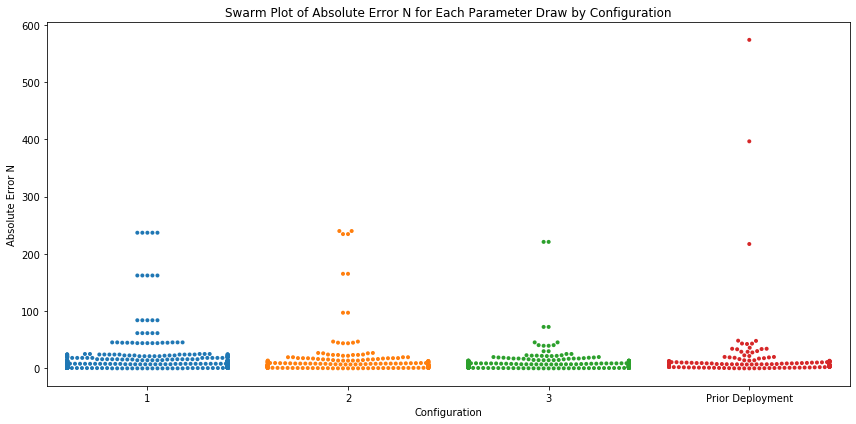

In [ ]:
df = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/Sensor Opt Experiments - Field Combo.csv')

df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 1000]

df_filtered['Configuration'] = df_filtered['Configuration'].astype(str)

# Plot a swarm plot with all 150 parameter draw values per configuration
plt.figure(figsize=(12, 6))
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    size=4
)
plt.title('Swarm Plot of Absolute Error N for Each Parameter Draw by Configuration')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()



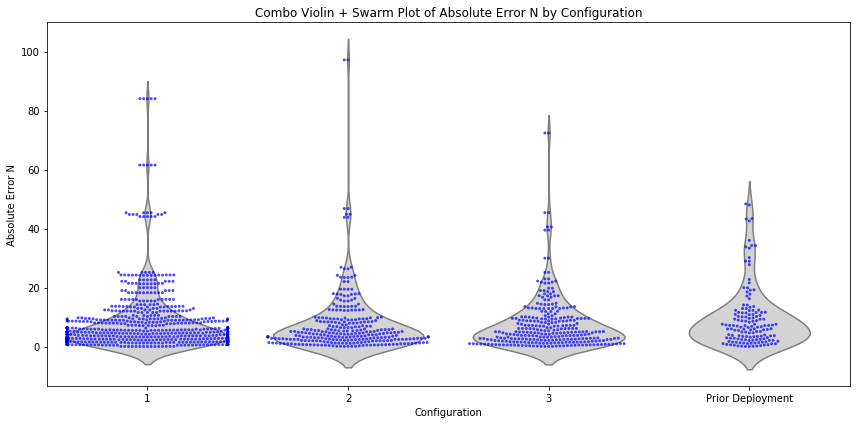

In [ ]:

# Exclude missing values and 'Absolute Error N' > 1000
df_filtered = df.dropna(subset=['Absolute Error N'])
df_filtered = df_filtered[df_filtered['Absolute Error N'] <= 100]

# Convert "Configuration" to string for clear labels
df_filtered['Configuration'] = df_filtered['Configuration'].astype(str)

plt.figure(figsize=(12, 6))
# Plot the violin plot
sns.violinplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    inner=None,      # Hide internal marks so swarm plot is clear
    color='lightgray'
)
# Overlay the swarm plot
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=df_filtered,
    size=3,
    color='blue',
    alpha=0.7
)
plt.title('Combo Violin + Swarm Plot of Absolute Error N by Configuration')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()


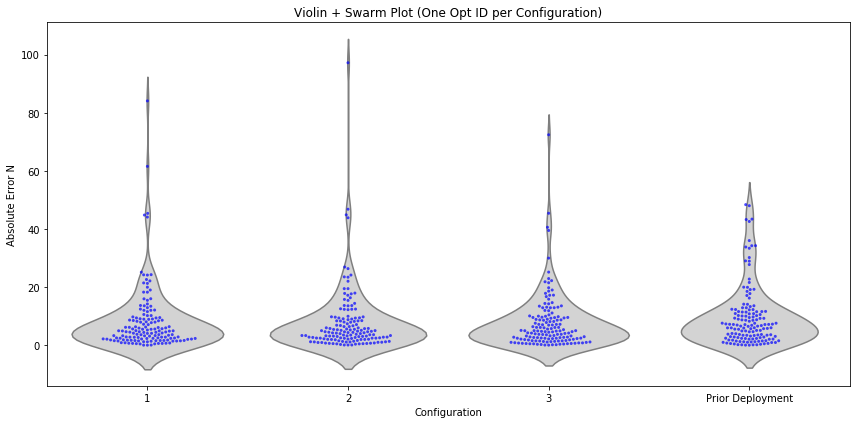

In [ ]:
# For each configuration, pick ONE opt id (here: the first opt ID encountered for each configuration)
chosen = df_filtered.groupby('Configuration')['Optimization ID'].first().reset_index()
# Filter DF to keep only those Opt IDs
filtered_one_per_config = df_filtered.merge(chosen, on=['Configuration', 'Optimization ID'])

# Plot violin+swarm using only one Opt ID per configuration
plt.figure(figsize=(12, 6))
sns.violinplot(
    x='Configuration',
    y='Absolute Error N',
    data=filtered_one_per_config,
    inner=None,
    color='lightgray'
)
sns.swarmplot(
    x='Configuration',
    y='Absolute Error N',
    data=filtered_one_per_config,
    size=3,
    color='blue',
    alpha=0.7
)
plt.title('Violin + Swarm Plot (One Opt ID per Configuration)')
plt.xlabel('Configuration')
plt.ylabel('Absolute Error N')
plt.tight_layout()
plt.show()


### Forward Greedy with Base

In [ ]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates as numpy array
coords = traps_df[['x', 'y']].to_numpy()

# Calculate the pairwise distance matrix
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs once (i < j to avoid duplicates)
unique_pairs = [
    (int(traps_df.iloc[i]['Trap_index']), int(traps_df.iloc[j]['Trap_index']))
    for i, j in zip(pairs[0], pairs[1]) if i < j
]

# Example: print the results
for pair in unique_pairs:
    print(pair)


(1, 29)
(1, 778)
(1, 779)
(1, 780)
(1, 809)
(2, 35)
(2, 36)
(2, 37)
(2, 783)
(2, 785)
(2, 808)
(3, 19)
(3, 788)
(3, 789)
(3, 790)
(3, 792)
(3, 1310)
(4, 22)
(4, 510)
(4, 511)
(4, 955)
(4, 966)
(5, 551)
(5, 552)
(5, 569)
(5, 572)
(5, 1363)
(5, 1364)
(6, 7)
(6, 350)
(6, 353)
(6, 401)
(6, 404)
(6, 1354)
(7, 8)
(7, 350)
(7, 351)
(7, 353)
(7, 354)
(8, 351)
(8, 352)
(8, 354)
(8, 712)
(9, 27)
(9, 522)
(9, 523)
(9, 524)
(9, 960)
(10, 11)
(10, 494)
(11, 422)
(12, 568)
(12, 570)
(12, 571)
(12, 573)
(12, 575)
(12, 576)
(12, 1028)
(12, 1029)
(12, 1364)
(12, 1365)
(13, 14)
(13, 421)
(13, 422)
(13, 427)
(13, 429)
(14, 421)
(14, 502)
(14, 503)
(15, 16)
(15, 498)
(15, 500)
(15, 501)
(15, 502)
(15, 503)
(15, 574)
(15, 579)
(15, 1366)
(16, 17)
(16, 502)
(16, 503)
(16, 504)
(17, 502)
(17, 503)
(17, 504)
(18, 625)
(18, 972)
(18, 1308)
(19, 611)
(19, 789)
(19, 790)
(19, 792)
(19, 1310)
(20, 21)
(20, 611)
(20, 612)
(20, 789)
(20, 792)
(20, 793)
(20, 1309)
(21, 611)
(21, 612)
(21, 789)
(21, 792)
(21, 793)
(2

In [ ]:
print(len(unique_pairs), "pairs found within 500m distance.")

3392 pairs found within 500m distance.


In [ ]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail_1km/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates and indices
coords = traps_df[['x', 'y']].to_numpy()
trap_indices = traps_df['Trap_index'].to_numpy()

# Calculate pairwise distances
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs with i < j to avoid duplicates
unique_pairs = [(i, j) for i, j in zip(pairs[0], pairs[1]) if i < j]

# Track cameras to remove (we will remove the second camera in each pair)
to_remove_indices = set(j for i, j in unique_pairs)

# Alternative: if you want a deterministic removal to avoid removing multiple times,
# you can also do a greedy approach removing cameras, but the above is simplest

# Indices of cameras to keep
all_indices = set(range(len(traps_df)))
to_keep_indices = all_indices - to_remove_indices

# Filter original dataframe by kept indices
remaining_cameras = traps_df.iloc[list(to_keep_indices)]

print(f"Number of cameras before removal: {len(traps_df)}")
print(f"Number of cameras after removal: {len(remaining_cameras)}")

# Optional: Save remaining cameras to a new CSV
# remaining_cameras.to_csv('remaining_cameras.csv', index=False)


Number of cameras before removal: 1465
Number of cameras after removal: 288


In [ ]:
ac_coords = pyreadr.read_r('./only_trail_1km/mask_7-30-25.RDS')
ac_coords = ac_coords[None]
ac_coords_list = ac_coords[['x', 'y']].values.tolist()
ac_coords_list = np.array(ac_coords_list)
ac_coords_list

array([[ 508737.78721529, 5623510.46939679],
       [ 509237.78721529, 5623510.46939679],
       [ 509737.78721529, 5623510.46939679],
       ...,
       [ 491737.78721529, 5674010.46939679],
       [ 492237.78721529, 5674010.46939679],
       [ 492737.78721529, 5674010.46939679]])

In [ ]:
# what x,y coords in scrpy/pgaff-testing/secr/Prior Deployment/deployed_cams_2024.csv are not in the scrpy/pgaff-testing/only_trail/500m/trail_candidate_traps_spacing500.csv?

deployed_cams = pd.read_csv('./secr/Prior Deployment/P1/deployed_cams_2024.csv')
deployed_cams_coords = deployed_cams[['x', 'y']].values.tolist()
deployed_cams_coords = np.array(deployed_cams_coords)

candidate_cams = pd.read_csv('./only_trail_1km/500m/trail_candidate_traps_spacing500.csv')
candidate_cams_coords = candidate_cams[['x', 'y']].values.tolist()
candidate_cams_coords = np.array(candidate_cams_coords)
# Find the coordinates in deployed_cams_coords that are not in candidate_cams_coords
missing_coords = []
for coord in deployed_cams_coords:
    if not any(np.array_equal(coord, candidate_coord) for candidate_coord in candidate_cams_coords):
        missing_coords.append(coord)
missing_coords = np.array(missing_coords)
print(len(missing_coords))


68


In [ ]:
true_n = pd.read_csv('./only_trail_1km/True_N_per_draw.csv')
# valid_ids = true_n['Parameter_draw'].tolist()                               # Change this if you want to filter with parameter draws in between some values of N or g0

params = pd.read_csv('./only_trail_1km/param_values_for_each_draw150.csv')
params = params.rename(columns={'Unnamed: 0': 'index'})
params = params.sample(n=50).reset_index(drop=True)                          # Randomly select 5 draws
# params = params[params['index'].isin(valid_ids)].iloc[:5]
print(f"Using {params['index'].tolist()} parameter draws")

D, g0, sigma = params['D'].values, params['g0'].values, params['sigma'].values
draw = params['index'].tolist()
draw_to_trueN = dict(zip(true_n['Parameter_draw'], true_n['N']))

# Gather all potential activity center locations
ac_coords = pyreadr.read_r('./only_trail_1km/mask_7-30-25.RDS')[None]
ac_coords_list = ac_coords[['x', 'y']].values

# Load full possible trap grid
full_trap_grid = pd.read_csv('./only_trail_1km/500m/trail_candidate_traps_spacing500.csv').drop(columns=['Unnamed: 0'])
full_trap_grid = full_trap_grid.rename(columns={'X': 'x', 'Y': 'y'})

# Candidate traps after 50m accessibility filter
# excluded_ids = pd.read_csv('./500m_data/traps_to_remove_50m.csv')['TrapID']
# candidate_grid = full_trap_grid[~full_trap_grid['Trap_index'].isin(excluded_ids)].copy()
candidate_grid = full_trap_grid.copy()

# Load all 68 deployed traps
# deployed_df = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')
# deployed_df = deployed_df[['x', 'y', 'Trap_index']]  # assuming correct format from file
deployed_df = full_trap_grid[full_trap_grid['Prior_cam']==1].copy()
deployed_df

candidate_exclusive = candidate_grid[~candidate_grid['Trap_index'].isin(deployed_df['Trap_index'])][['x', 'y', 'Trap_index']]

candidate_exclusive

Using [4, 9, 18, 61, 107, 45, 95, 24, 49, 58, 106, 33, 131, 139, 40, 97, 85, 37, 80, 71, 109, 133, 31, 117, 146, 51, 67, 87, 65, 11, 89, 14, 122, 98, 137, 144, 26, 42, 62, 147, 53, 74, 88, 83, 8, 15, 141, 56, 66, 119] parameter draws


,x,y,Trap_index
0,510670.337539,5.634173e+06,1
1,510589.866136,5.636167e+06,2
2,511461.885975,5.637240e+06,3
3,516098.336526,5.638313e+06,4
4,514871.344999,5.641862e+06,5
...,...,...,...
1390,502867.143885,5.653349e+06,1391
1391,502779.344158,5.652899e+06,1392
1392,514477.896293,5.639606e+06,1393
1393,514898.265452,5.639352e+06,1394


### File Manipulation

In [ ]:
# put the Traps IDs that have a Prior_cam value of 0 into the txt file based on the data in scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv

# File paths
input_csv = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail_1km/500m/trail_candidate_traps_spacing500.csv"
output_txt = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/P3/P3-excluded_traps.txt"

# Change these variables if your columns have different names
trap_id_column = 'Trap_index'     # Replace with the actual Trap ID column name
prior_cam_column = 'Prior_cam' # Replace with the actual Prior_cam column name

trap_ids = []

# Read the CSV and extract Trap IDs
with open(input_csv, newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        if row[prior_cam_column] == '0' or row[prior_cam_column] == 0:
            trap_ids.append(row[trap_id_column])

# Write Trap IDs to a txt file
with open(output_txt, 'w', encoding='utf-8') as txtfile:
    for trap_id in trap_ids:
        txtfile.write(f"{trap_id}\n")

print(f"Extracted {len(trap_ids)} Trap IDs to '{output_txt}'.")


Extracted 1395 Trap IDs to '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Prior Deployment/P3/P3-excluded_traps.txt'.


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG11/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 20:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 20 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG11/selected_traps-20.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG11/BG11-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
# find the lat longs in scrpy/pgaff-testing/500m_data/SCM_deployed_cams_2024.csv that are not in 500m_trap_grid.csv
deployed_cams = pd.read_csv('deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})
# merge with trap_coords to find the traps that are not in the grid
deployed_cams = deployed_cams.merge(trap_coords, on=['x', 'y'], how='left')

In [ ]:
deployed_cams.to_csv('secr/Prior Deployment/deployed_cams_2024.csv', index=False)

In [ ]:
# Load the deployed cameras file and rename coordinate columns for consistency
deployed_cams = pd.read_csv('500m_data/SCM_deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})

# Load the full trap grid
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')

# Identify grid records (by x,y) that are not present in deployed cameras
not_in_deployed = trap_coords[
    ~trap_coords[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]

not_in_deployed

not_in_deployed['Trap_index'].to_csv('not_in_2019_deployment.txt', index=False, header=False)


# with open('secr/2019 Deployment/deployed_cams_not_in_grid.txt', 'w') as f:
#     for item in deployed_cams_not_in_grid['TrapID']:
#         f.write("%s\n" % item)

In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
# selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:

# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:68]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-68.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
trap_coords = pd.read_csv('./500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.drop(columns = ['Unnamed: 0'])
exclude_trap_coords = pd.read_csv('./500m_data/traps_to_remove_50m.csv')
trap_coords = trap_coords[~trap_coords['Trap_index'].isin(exclude_trap_coords['TrapID'])]
trap_coords_list = []
for i in range(trap_coords.shape[0]):
    trap_coords_list.append((trap_coords['x'].iloc[i], trap_coords['y'].iloc[i]))
trap_coords_list = np.array(trap_coords_list)
print(f"{trap_coords_list.shape} candidate trap locations")

trap_coords_list_df = pd.DataFrame(trap_coords_list, columns=['x', 'y'])
trap_coords_list_df.to_csv('./secr/Random/R3/considered_trap_locs.csv', index=False)

# randomly select 68 of the trap locations
selected_traps = np.random.choice(trap_coords_list.shape[0], size=68, replace=False)
trap_coords_list_sub_df = trap_coords_list_df.iloc[selected_traps]


# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Random/R3/selected_traps.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Random/R3/R3-excluded_traps.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

(258, 2) candidate trap locations
Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
exclude_trap_coords

,TrapID,X,Y
0,1,509737.787215,5.633510e+06
1,2,510237.787215,5.633510e+06
2,3,510737.787215,5.633510e+06
3,4,511237.787215,5.633510e+06
4,5,509237.787215,5.634010e+06
...,...,...,...
2174,2433,496737.787215,5.663510e+06
2175,2434,489737.787215,5.664010e+06
2176,2435,490237.787215,5.664010e+06
2177,2436,490737.787215,5.664010e+06


### Costing Surfaces

In [ ]:
traps = pd.read_csv('./500m_data/500m_trap_grid.csv')
deployed_cams = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')

# Identify traps that are not in deployed_cams
not_in_deployed = traps[
    ~traps[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]
not_in_deployed

not_in_deployed.to_csv('traps_to_remove_prior.csv')

In [ ]:
not_in_deployed

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [ ]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 500
costing_surface_allowed = costing_surface[~(costing_surface['rel_cost'].isna()) & ~(costing_surface['Distance_to_trail_m'] > 500.00)]
costing_surface_allowed

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
60,61,61,431.303809,916.542688,0.081414,508737.7872,5637010.469
61,62,62,361.697779,861.470553,0.076522,509237.7872,5637010.469
62,63,63,376.082558,818.130720,0.072672,509737.7872,5637010.469
63,64,64,370.426454,864.657365,0.076805,510237.7872,5637010.469
65,66,66,441.168219,877.416023,0.077938,511237.7872,5637010.469
...,...,...,...,...,...,...,...
2428,2429,2429,248.762323,3529.317834,0.313499,494737.7872,5663510.469
2429,2430,2430,116.778259,3468.382344,0.308086,495237.7872,5663510.469
2430,2431,2431,25.001649,3496.168778,0.310554,495737.7872,5663510.469
2431,2432,2432,252.564797,3635.222101,0.322906,496237.7872,5663510.469


In [ ]:
# from selected_traps.csv in FG11, return a csv that has just the x,y coordinates of those that are not in deployed_cams_2024.csv
selected_traps = pd.read_csv('secr/Forward Greedy/FG11/selected_traps-20.csv')


In [29]:
ac_files = glob.glob('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/full_grid_1km/10-3 data (Marten)/Constant_detection/AC_locations/*.csv')


ac_coords = []
for file in ac_files:
    df = pd.read_csv(file)
    if 'x' in df.columns and 'y' in df.columns:
        ac_coords.append(df[['x', 'y']])

ac_coords_df = pd.concat(ac_coords, ignore_index=True)

ac_coords_df.to_csv('combined_ac_coords_10-3_marten.csv', index=False)
print("Combined coordinates saved")


Combined coordinates saved


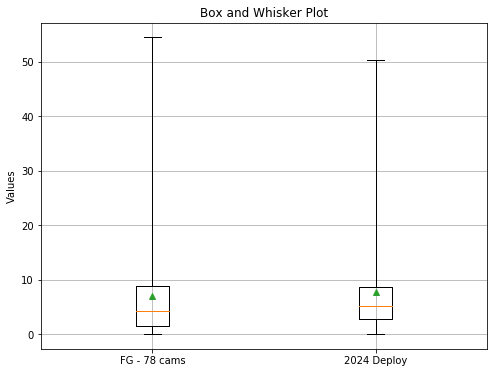

In [ ]:
import matplotlib.pyplot as plt

# Summary statistics
labels = ['FG - 78 cams', '2024 Deploy']
min_vals = [0.049, 0.026]
q1 = [1.54, 2.72]
median = [4.22, 5.08]
q3 = [8.77, 8.58]
max_vals = [54.47, 50.25]
means = [6.97, 7.76]

# Prepare boxplot data for matplotlib's bxp() function
box_data = []
for i in range(len(labels)):
    box_data.append({
        'label': labels[i],
        'whislo': min_vals[i],     # Lower whisker (min)
        'q1': q1[i],               # First quartile (Q1)
        'med': median[i],          # Median (Q2)
        'q3': q3[i],               # Third quartile (Q3)
        'whishi': max_vals[i],     # Upper whisker (max)
        'mean': means[i],          # Mean (optional)
        'fliers': []               # No outliers available
    })

# Create the box and whisker plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.bxp(box_data, showmeans=True)
ax.set_ylabel('Values')
ax.set_title('Box and Whisker Plot')
ax.grid(True)
plt.show()


In [ ]:
# add the data from all the files in AC_locations into a singular csv file.


In [ ]:
costing_surface_disallowed = costing_surface[(costing_surface['rel_cost'].isna()) | (costing_surface['Distance_to_trail_m'] > 500.00)]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['Trap_index', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_cost_500m.csv', index=False)

In [ ]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 50
costing_surface_allowed = costing_surface[~(costing_surface['Rel_cost'].isna())]
costing_surface_allowed


costing_surface_disallowed = costing_surface[(costing_surface['Rel_cost'].isna())]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['TrapID', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_50m.csv', index=False)

In [ ]:
costing_surface

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
0,1,1,3842.015535,NaN,NaN,509737.7872,5633510.469
1,2,2,3855.952509,NaN,NaN,510237.7872,5633510.469
2,3,3,3874.371793,NaN,NaN,510737.7872,5633510.469
3,4,4,3822.221227,NaN,NaN,511237.7872,5633510.469
4,5,5,3355.109326,NaN,NaN,509237.7872,5634010.469
...,...,...,...,...,...,...,...
2432,2433,2433,171.146726,3789.301023,0.336592,496737.7872,5663510.469
2433,2434,2434,4130.440150,NaN,NaN,489737.7872,5664010.469
2434,2435,2435,3668.201922,NaN,NaN,490237.7872,5664010.469
2435,2436,2436,3217.277553,NaN,NaN,490737.7872,5664010.469


In [ ]:
import numpy as np

def average_diff_and_abs_diff_for_iteration(file_path, iteration_num):
    """
    Returns both the average error (Diff, signed)
    and the average absolute error (|Diff|) for the given iteration.
    """
    diffs = []
    with open(file_path, 'r') as f:
        found_iter = False
        target_iter_line = f"Iteration {iteration_num}:"
        for line in f:
            if line.strip().startswith(target_iter_line):
                found_iter = True
                continue
            if found_iter:
                if line.strip().startswith('Iteration'):
                    # Reached next iteration, stop reading further
                    break
                if 'Diff=' in line:
                    try:
                        diff_value = float(line.split('Diff=')[1].strip())
                        diffs.append(diff_value)
                    except ValueError:
                        continue
    if not diffs:
        print(f"No 'Diff' values found for iteration {iteration_num}.")
        return None, None
    average_error = np.mean(diffs)
    average_abs_error = np.mean(np.abs(diffs))
    print(f"Average Error for iteration {iteration_num}: {average_error}")
    print(f"Average Absolute Error for iteration {iteration_num}: {average_abs_error}")
    return average_error, average_abs_error

# Example usage:
file_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Backward Greedy/BG8/n_tracker.txt'
iteration_num = 238  # Change to desired iteration
average_diff_and_abs_diff_for_iteration(file_path, iteration_num)


Average Error for iteration 238: -32.418700740400105
Average Absolute Error for iteration 238: 32.418700740400105


(-32.418700740400105, 32.418700740400105)

In [ ]:
# In each capture history file, determine what individuals and how many were observed.
def get_individuals(capture_history_file):
    """
    Return the unique number of individuals in the 'individual' column
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individuals = set()
        for row in reader:
            individual = row['individual']
            individuals.add(individual)
    return individuals

def get_recaptures(capture_history_file):
    """
    Return the number of individuals that have been captured more than once.
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individual_counts = {}
        for row in reader:
            individual = row['individual']
            if individual in individual_counts:
                individual_counts[individual] += 1
            else:
                individual_counts[individual] = 1
        # Count individuals with more than one capture
        recaptures = sum(1 for count in individual_counts.values() if count > 1)
    return recaptures


def get_spatial_recaptures(capture_history_file):
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)        
        individual_locations = {}
        for row in reader:
            indv = row['individual']
            loc = (row['trap_id'])
            if indv not in individual_locations:
                individual_locations[indv] = set()
            individual_locations[indv].add(loc)
        
        # Count individuals with >1 unique location
        return sum(1 for locs in individual_locations.values() if len(locs) > 1)


# run for all the files in pgaff-testing/500m_data/capture_history/
def process_capture_history_files(directory):
    """
    Process all capture history files in the given directory.
    """
    results = []
    for filename in tqdm(os.listdir(directory)):
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            individuals = get_individuals(file_path)
            recaptures = get_recaptures(file_path)
            spatial_recaptures = get_spatial_recaptures(file_path)
            results.append({
                'file': filename,
                'individuals': len(individuals),
                'recaptures': recaptures,
                'spatial_recaptures': spatial_recaptures           
                })
    # return results as a dataframe with the number at the end of the cpature history file then the unique individuals detected in the other column
    results_df = pd.DataFrame(results)
    results_df['capture_history'] = results_df['file'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else None)
    # convert both columsn to integers
    results_df['capture_history'] = results_df['capture_history'].astype(int)
    results_df = results_df[['capture_history', 'individuals', 'recaptures', 'spatial_recaptures']]
    results_df['observations'] = results_df['individuals'].astype(int)
    results_df['recaptures'] = results_df['recaptures'].astype(int)
    results_df['spatial_recaptures'] = results_df['spatial_recaptures'].astype(int)
    results_df = results_df.sort_values(by='capture_history')
    results_df.reset_index(drop=True, inplace=True)
    # Save the results to a CSV file
    output_file = os.path.join(directory, 'individuals_observed.csv')
    results_df.to_csv(output_file, index=False)
    return results_df

process_capture_history_files('only_trail_1km/500m/ch')  # Adjust the path as needed

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [00:03<00:00, 40.51it/s]


,capture_history,individuals,recaptures,spatial_recaptures,observations
0,1,49,41,41,49
1,2,22,18,18,22
2,3,51,51,51,51
3,4,80,75,75,80
4,5,23,17,17,23
...,...,...,...,...,...
145,146,45,39,39,45
146,147,77,70,70,77
147,148,20,18,17,20
148,149,34,30,30,34


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG3/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG3/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG3/selected_traps_20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG3/FG3-excluded_traps_20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [ ]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG8/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 68:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 68 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG8/selected_traps-68.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG8/BG8-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [33]:
trap_coords = pd.read_csv('./full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv')
trap_coords = trap_coords.drop(columns = ['Unnamed: 0'])
# exclude_trap_coords = pd.read_csv('./500m_data/traps_to_remove_50m.csv')
exclude_trap_coords = pd.read_csv('./full_grid_1km/traps_to_remove_1km.csv')
trap_coords = trap_coords[~trap_coords['Trap_index'].isin(exclude_trap_coords['Trap_index'])]
trap_coords_list = []
for i in range(trap_coords.shape[0]):
    trap_coords_list.append((trap_coords['x'].iloc[i], trap_coords['y'].iloc[i]))
trap_coords_list = np.array(trap_coords_list)
print(f"{trap_coords_list.shape} candidate trap locations")
trap_coords_list_df = pd.DataFrame(trap_coords_list, columns=['x', 'y'])

base_dir = './secr/Forward Greedy/FGM1'

selected_traps = [621, 586, 620, 656, 655, 654, 690, 691, 657, 812, 622, 811, 777, 776, 658, 
                    624, 623, 659, 625, 660, 689, 693, 694, 692, 986, 619, 695, 682, 653, 618, 583, 584,
                     585, 582, 617, 847, 775, 446, 626, 661, 696, 587, 683, 648, 741, 649, 647, 681, 1021, 481, 
                     447, 482, 480, 445, 479, 969, 26, 650, 684, 614, 615, 616, 651, 685, 652, 613, 866, 686, 784, 688, 1022, 987, 742, 61, 62, 27, 97, 96, 590, 591]

# Use trap_coords DataFrame which contains trap IDs

for n_cams in [10, 20, 30, 40, 50, 60, 70, 80]:
    traps_subset = selected_traps[:n_cams]

    trap_coords_list_sub_df = trap_coords[trap_coords['Trap_index'].isin(traps_subset)].copy()
    trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df['Trap_index']  # Keep IDs as-is

    trap_csv_path = f'{base_dir}/selected_traps_{n_cams}.csv'
    trap_coords_list_sub_df.to_csv(trap_csv_path, index=False)  # Index can be False if IDs are in data

    all_trap_ids = set(trap_coords['Trap_index'])
    selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])
    excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

    excluded_txt_path = f'{base_dir}/FGM1-excluded_traps-{n_cams}.txt'
    with open(excluded_txt_path, 'w') as f:
        for item in excluded_trap_ids:
            f.write(f"{item}\n")

    print(f"[{n_cams} cams] Selected {len(traps_subset)} traps, "
          f"Excluded {len(excluded_trap_ids)} traps, "
          f"Total traps in full grid: {len(all_trap_ids)}")
    print(f"   Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} = {len(all_trap_ids)}")



(1023, 2) candidate trap locations
[10 cams] Selected 10 traps, Excluded 1013 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[20 cams] Selected 20 traps, Excluded 1003 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[30 cams] Selected 30 traps, Excluded 993 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[40 cams] Selected 40 traps, Excluded 985 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[50 cams] Selected 50 traps, Excluded 975 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[60 cams] Selected 60 traps, Excluded 965 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[70 cams] Selected 70 traps, Excluded 955 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023
[80 cams] Selected 80 traps, Excluded 945 traps, Total traps in full grid: 1023
   Verification: 1023 = 1023


In [ ]:
# for all the scnearios in scrpy/pgaff-testing/full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv report E_n, E_r and if E_n or E_r is smaller.

params = pd.read_csv('./full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv')
params = params.rename(columns={'Unnamed: 0': 'index'})

# Calculate E_n and E_r for each row


### Graphics for Papper

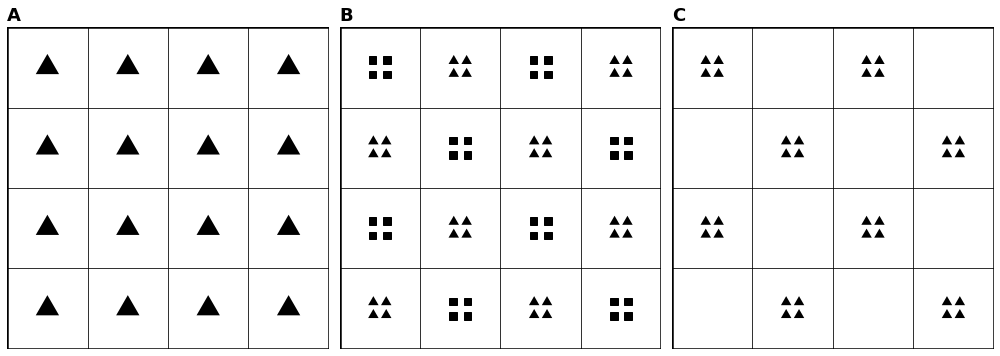

In [ ]:
def draw_triangle(ax, x_center, y_center, size=0.16):
    h = size * np.sqrt(3) / 2
    triangle = np.array([
        [x_center - size/2, y_center - h/3],
        [x_center + size/2, y_center - h/3],
        [x_center, y_center + 2*h/3]
    ])
    ax.fill(triangle[:, 0], triangle[:, 1], 'k')

def draw_2x2_triangles(ax, x_center, y_center, size=0.13, gap=0.06):
    # Draw a 2x2 grid of triangles centered at (x_center, y_center)
    offset = size / 1.3 + gap
    for dx in [-0.5, 0.5]:
        for dy in [-0.5, 0.5]:
            draw_triangle(ax,
                x_center + dx*offset,
                y_center + dy*offset,
                size)

def draw_window(ax, x_center, y_center, size=0.19):
    offset = size/2.1
    for dx in [-1, 1]:
        for dy in [-1, 1]:
            ax.add_patch(
                patches.Rectangle(
                    (x_center + dx*offset - size/4, y_center + dy*offset - size/4),
                    size/2, size/2, color='k'
                )
            )

def make_grid(ax, n, border=0.13):
    ax.set_xlim(-border, n-1+border)
    ax.set_ylim(-border, n-1+border)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(-0.5, n, 1))
    ax.set_yticks(np.arange(-0.5, n, 1))
    ax.grid(True, which='both', color='black', linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    rec = patches.Rectangle((-0.5,-0.5), width=n, height=n,
                            linewidth=2.5, edgecolor='black',
                            facecolor='none')
    ax.add_patch(rec)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)

def plot_first_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                draw_window(ax, j, n-1-i)
            else:
                draw_2x2_triangles(ax, j, n-1-i)

def plot_second_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            if (i + j) % 2 == 0:
                draw_2x2_triangles(ax, j, n-1-i)

def plot_third_chart(ax):
    n = 4
    make_grid(ax, n)
    for i in range(n):
        for j in range(n):
            draw_triangle(ax, j, n-1-i, size=0.29)

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
plot_first_chart(axs[1])    # Chart A
plot_second_chart(axs[2])   # Chart B
plot_third_chart(axs[0])    # Chart C

# Add bold labels above each chart
labels = ['A', 'B', 'C']
for i, ax in enumerate(axs):
    ax.text(-0.5, 3.75, labels[i], fontsize=18, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('triangle_charts.png', dpi=300, bbox_inches='tight')
plt.show()


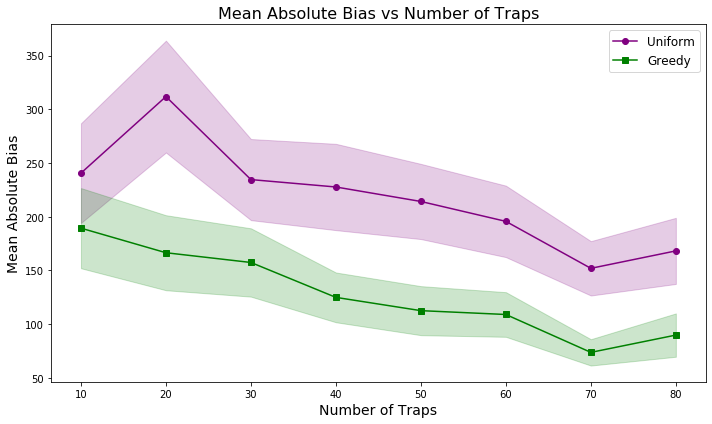

Paired t-test results per trap count:
Trap count 10: t-stat = 1.6057, p-value = 1.1376e-01
Trap count 20: t-stat = 5.1927, p-value = 1.2150e-06
Trap count 30: t-stat = 2.9709, p-value = 3.6675e-03
Trap count 40: t-stat = 4.4005, p-value = 2.4441e-05
Trap count 50: t-stat = 4.6387, p-value = 9.3482e-06
Trap count 60: t-stat = 4.5926, p-value = 1.1027e-05
Trap count 70: t-stat = 5.7082, p-value = 7.8530e-08
Trap count 80: t-stat = 4.0545, p-value = 8.5723e-05


In [27]:
import os
import glob
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci


def process_uniform_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


def process_greedy_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


# Get data and pooled samples for t-tests
uniform_means, uniform_cis, uniform_pooled = process_uniform_data(uniform_folder, True)
greedy_means, greedy_cis, greedy_pooled = process_greedy_data(greedy_folder, True)


plt.figure(figsize=(10, 6))
plt.plot(trap_counts, uniform_means, marker='o', color='purple', label='Uniform')
plt.fill_between(
    trap_counts,
    np.maximum(uniform_means - uniform_cis, 0),
    uniform_means + uniform_cis,
    color='purple', alpha=0.2
)
plt.plot(trap_counts, greedy_means, marker='s', color='green', label='Greedy')
plt.fill_between(
    trap_counts,
    np.maximum(greedy_means - greedy_cis, 0),
    greedy_means + greedy_cis,
    color='green', alpha=0.2
)
plt.title('Mean Absolute Bias vs Number of Traps', fontsize=16)
plt.xlabel('Number of Traps', fontsize=14)
plt.ylabel('Mean Absolute Bias', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# After plotting, output paired t-test results
print("Paired t-test results per trap count:")
for i, n in enumerate(trap_counts):
    uni_vals = uniform_pooled[i]
    gry_vals = greedy_pooled[i]
    min_len = min(len(uni_vals), len(gry_vals))
    if min_len < 2:
        print(f"Trap count {n}: Insufficient data for paired t-test")
        continue
    # Truncate for pairing
    uni_vals = uni_vals[:min_len]
    gry_vals = gry_vals[:min_len]
    t_stat, p_val = stats.ttest_rel(uni_vals, gry_vals)
    print(f"Trap count {n}: t-stat = {t_stat:.4f}, p-value = {p_val:.4e}")


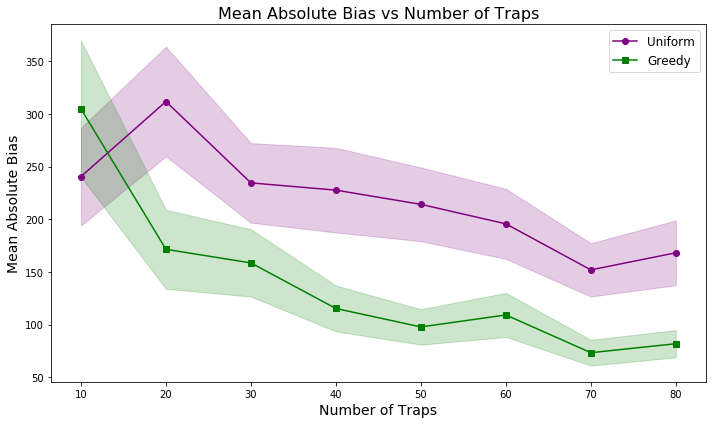

Paired t-test results per trap count:
Trap count 10: t-stat = -1.6381, p-value = 1.0690e-01
Trap count 20: t-stat = 4.2798, p-value = 4.5403e-05
Trap count 30: t-stat = 3.1422, p-value = 2.1694e-03
Trap count 40: t-stat = 4.9334, p-value = 2.7775e-06
Trap count 50: t-stat = 6.0213, p-value = 2.1204e-08
Trap count 60: t-stat = 4.6452, p-value = 8.8987e-06
Trap count 70: t-stat = 5.6642, p-value = 9.6376e-08
Trap count 80: t-stat = 5.4375, p-value = 2.5543e-07


In [47]:
####### SELECTED VIA RSE IN SAA####################
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/rse'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci


def process_uniform_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


def process_greedy_data(folder, filter_large_errors=True):
    mean_vals, ci_vals, pooled_values = [], [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
        pooled_values.append(np.array(pooled_errors))
    return np.array(mean_vals), np.array(ci_vals), pooled_values


# Get data and pooled samples for t-tests
uniform_means, uniform_cis, uniform_pooled = process_uniform_data(uniform_folder, True)
greedy_means, greedy_cis, greedy_pooled = process_greedy_data(greedy_folder, True)


plt.figure(figsize=(10, 6))
plt.plot(trap_counts, uniform_means, marker='o', color='purple', label='Uniform')
plt.fill_between(
    trap_counts,
    np.maximum(uniform_means - uniform_cis, 0),
    uniform_means + uniform_cis,
    color='purple', alpha=0.2
)
plt.plot(trap_counts, greedy_means, marker='s', color='green', label='Greedy')
plt.fill_between(
    trap_counts,
    np.maximum(greedy_means - greedy_cis, 0),
    greedy_means + greedy_cis,
    color='green', alpha=0.2
)
plt.title('Mean Absolute Bias vs Number of Traps', fontsize=16)
plt.xlabel('Number of Traps', fontsize=14)
plt.ylabel('Mean Absolute Bias', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# After plotting, output paired t-test results
print("Paired t-test results per trap count:")
for i, n in enumerate(trap_counts):
    uni_vals = uniform_pooled[i]
    gry_vals = greedy_pooled[i]
    min_len = min(len(uni_vals), len(gry_vals))
    if min_len < 2:
        print(f"Trap count {n}: Insufficient data for paired t-test")
        continue
    # Truncate for pairing
    uni_vals = uni_vals[:min_len]
    gry_vals = gry_vals[:min_len]
    t_stat, p_val = stats.ttest_rel(uni_vals, gry_vals)
    print(f"Trap count {n}: t-stat = {t_stat:.4f}, p-value = {p_val:.4e}")


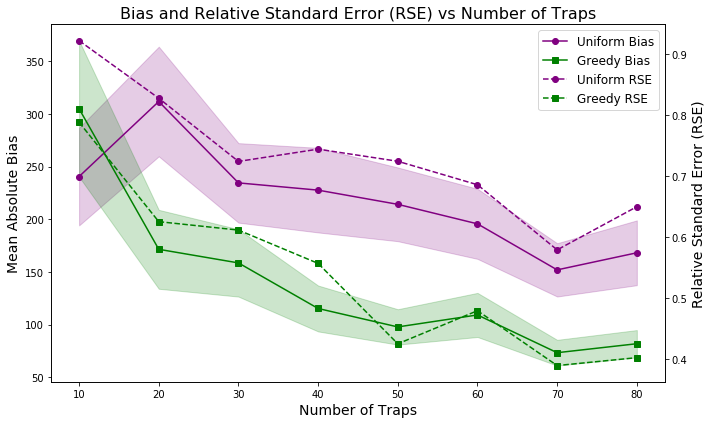

In [44]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Folder paths and trap counts (use your existing paths)
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# Function for RSE confidence interval calculation
def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2

# Function for 95% CI calculation of mean values
def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

# Process RSE data for Uniform and Greedy
def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Process Mean Absolute Bias data for Uniform and Greedy
def process_uniform_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'  # Assuming this is the bias file path pattern
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Load all data
uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder)
uniform_bias_means, uniform_bias_cis = process_uniform_bias(uniform_folder)
greedy_bias_means, greedy_bias_cis = process_greedy_bias(greedy_folder)

# Plotting with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Mean Absolute Bias with error bars on left y-axis
ax1.plot(trap_counts, uniform_bias_means, marker='o', color='purple', label='Uniform Bias')
ax1.fill_between(trap_counts,
                 np.maximum(uniform_bias_means - uniform_bias_cis, 0),
                 uniform_bias_means + uniform_bias_cis,
                 color='purple', alpha=0.2)
ax1.plot(trap_counts, greedy_bias_means, marker='s', color='green', label='Greedy Bias')
ax1.fill_between(trap_counts,
                 np.maximum(greedy_bias_means - greedy_bias_cis, 0),
                 greedy_bias_means + greedy_bias_cis,
                 color='green', alpha=0.2)

ax1.set_xlabel('Number of Traps', fontsize=14)
ax1.set_ylabel('Mean Absolute Bias', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis for RSE
ax2 = ax1.twinx()
ax2.plot(trap_counts, uniform_rse_means, marker='o', color='purple', linestyle='--', label='Uniform RSE')
# ax2.fill_between(trap_counts,
#                  np.maximum(uniform_rse_means - uniform_rse_cis, 0),
#                  uniform_rse_means + uniform_rse_cis,
#                  color='purple', alpha=0.1)
ax2.plot(trap_counts, greedy_rse_means, marker='s', color='green', linestyle='--', label='Greedy RSE')
# ax2.fill_between(trap_counts,
#                  np.maximum(greedy_rse_means - greedy_rse_cis, 0),
#                  greedy_rse_means + greedy_rse_cis,
#                  color='green', alpha=0.1)

ax2.set_ylabel('Relative Standard Error (RSE)', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=12, loc='upper right')

plt.title('Bias and Relative Standard Error (RSE) vs Number of Traps', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_combined_bias_rse.png', dpi=300, bbox_inches='tight')
plt.show()


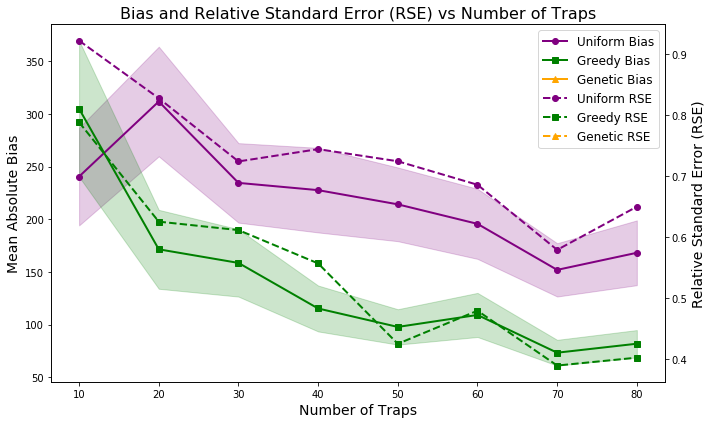

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Folder paths and trap counts
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
genetic_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4/test_results/RSE/SAA3-SA18'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# Function for RSE confidence interval calculation
def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2

# Function for 95% CI calculation of mean values
def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

# Process RSE data for Uniform and Greedy (unchanged)
def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# NEW: Process Genetic Algorithm RSE data
def process_genetic_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA18-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Process Mean Absolute Bias data (same functions, just add Genetic)
def process_uniform_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_genetic_bias(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SAA3-SA18-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df['N_abs_error'].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Load all data
uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder)
genetic_rse_means, genetic_rse_cis = process_genetic_rse(genetic_folder)

uniform_bias_means, uniform_bias_cis = process_uniform_bias(uniform_folder)
greedy_bias_means, greedy_bias_cis = process_greedy_bias(greedy_folder)
genetic_bias_means, genetic_bias_cis = process_genetic_bias(genetic_folder)

# Plotting with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Mean Absolute Bias with error bars on left y-axis (solid lines)
ax1.plot(trap_counts, uniform_bias_means, marker='o', color='purple', label='Uniform Bias', linewidth=2)
ax1.fill_between(trap_counts,
                 np.maximum(uniform_bias_means - uniform_bias_cis, 0),
                 uniform_bias_means + uniform_bias_cis,
                 color='purple', alpha=0.2)
ax1.plot(trap_counts, greedy_bias_means, marker='s', color='green', label='Greedy Bias', linewidth=2)
ax1.fill_between(trap_counts,
                 np.maximum(greedy_bias_means - greedy_bias_cis, 0),
                 greedy_bias_means + greedy_bias_cis,
                 color='green', alpha=0.2)
ax1.plot(trap_counts, genetic_bias_means, marker='^', color='orange', label='Genetic Bias', linewidth=2)
ax1.fill_between(trap_counts,
                 np.maximum(genetic_bias_means - genetic_bias_cis, 0),
                 genetic_bias_means + genetic_bias_cis,
                 color='orange', alpha=0.2)

ax1.set_xlabel('Number of Traps', fontsize=14)
ax1.set_ylabel('Mean Absolute Bias', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis for RSE (dashed lines)
ax2 = ax1.twinx()
ax2.plot(trap_counts, uniform_rse_means, marker='o', color='purple', linestyle='--', label='Uniform RSE', linewidth=2)
ax2.plot(trap_counts, greedy_rse_means, marker='s', color='green', linestyle='--', label='Greedy RSE', linewidth=2)
ax2.plot(trap_counts, genetic_rse_means, marker='^', color='orange', linestyle='--', label='Genetic RSE', linewidth=2)

ax2.set_ylabel('Relative Standard Error (RSE)', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=12, loc='upper right')

plt.title('Bias and Relative Standard Error (RSE) vs Number of Traps', fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.savefig('marten_uniform_greedy_genetic_combined_bias_rse.png', dpi=300, bbox_inches='tight')
plt.show()


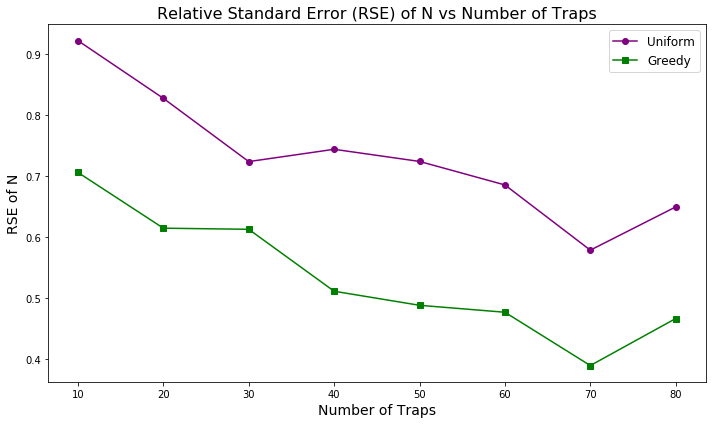

<Figure size 432x288 with 0 Axes>

In [ ]:

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)   # Avoid divide by zero
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    # For CI, resample RSE by bootstrapping
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2   # Half-width as approx CI

def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Get RSE data
uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder, True)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder, True)

plt.figure(figsize=(10, 6))
plt.plot(trap_counts, uniform_rse_means, marker='o', color='purple', label='Uniform')
# plt.fill_between(
#     trap_counts,
#     np.maximum(uniform_rse_means - uniform_rse_cis, 0),
#     uniform_rse_means + uniform_rse_cis,
#     color='purple', alpha=0.2
# )
plt.plot(trap_counts, greedy_rse_means, marker='s', color='green', label='Greedy')
# plt.fill_between(
#     trap_counts,
#     np.maximum(greedy_rse_means - greedy_rse_cis, 0),
#     greedy_rse_means + greedy_rse_cis,
#     color='green', alpha=0.2
# )
plt.title('Relative Standard Error (RSE) of N vs Number of Traps', fontsize=16)
plt.xlabel('Number of Traps', fontsize=14)
plt.ylabel('RSE of N', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()
plt.savefig('marten_uniform_greedy_RSE_comparison.png', dpi=300, bbox_inches='tight')


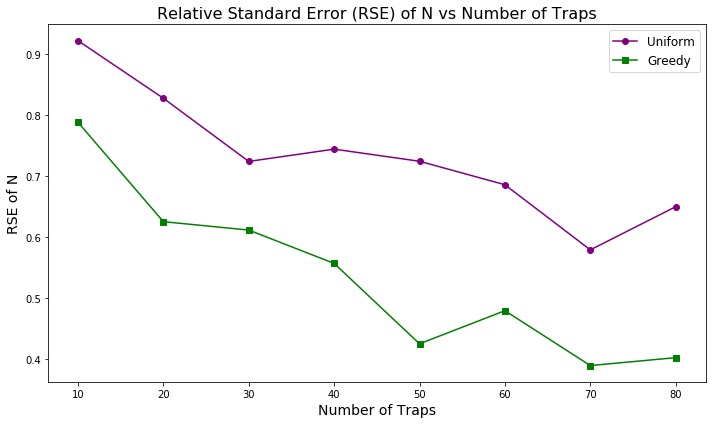

<Figure size 432x288 with 0 Axes>

In [45]:
####### SELECTED VIA RSE IN SAA####################

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)   # Avoid divide by zero
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    # For CI, resample RSE by bootstrapping
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2   # Half-width as approx CI

def process_uniform_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

def process_greedy_rse(folder, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, ci = calc_rse_ci(pooled_nestimates)
        mean_vals.append(rse)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Get RSE data
uniform_rse_means, uniform_rse_cis = process_uniform_rse(uniform_folder, True)
greedy_rse_means, greedy_rse_cis = process_greedy_rse(greedy_folder, True)

plt.figure(figsize=(10, 6))
plt.plot(trap_counts, uniform_rse_means, marker='o', color='purple', label='Uniform')
# plt.fill_between(
#     trap_counts,
#     np.maximum(uniform_rse_means - uniform_rse_cis, 0),
#     uniform_rse_means + uniform_rse_cis,
#     color='purple', alpha=0.2
# )
plt.plot(trap_counts, greedy_rse_means, marker='s', color='green', label='Greedy')
# plt.fill_between(
#     trap_counts,
#     np.maximum(greedy_rse_means - greedy_rse_cis, 0),
#     greedy_rse_means + greedy_rse_cis,
#     color='green', alpha=0.2
# )
plt.title('Relative Standard Error (RSE) of N vs Number of Traps', fontsize=16)
plt.xlabel('Number of Traps', fontsize=14)
plt.ylabel('RSE of N', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()
plt.savefig('marten_uniform_greedy_RSE_comparison.png', dpi=300, bbox_inches='tight')


In [ ]:
####### SELECTED VIA RSE IN SAA####################
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]


def calc_rse_ci(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    boot_rse = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rse.append(np.std(sample) / np.mean(sample))
    ci = np.percentile(boot_rse, [2.5, 97.5])
    return rse, (ci[1] - ci[0]) / 2


def process_uniform_rse_lists(folder, filter_large_errors=True):
    rse_lists = []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse_lists.append(pooled_nestimates)
    return rse_lists


def process_greedy_rse_lists(folder, filter_large_errors=True):
    rse_lists = []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse_lists.append(pooled_nestimates)
    return rse_lists


uniform_rse_lists = process_uniform_rse_lists(uniform_folder, True)
greedy_rse_lists = process_greedy_rse_lists(greedy_folder, True)


# Now perform paired t-tests for each trap count between uniform and greedy RSE values
for i, n in enumerate(trap_counts):
    uniform_vals = uniform_rse_lists[i]
    greedy_vals = greedy_rse_lists[i]

    # Make sure the two lists have the same length for paired t-test
    min_len = min(len(uniform_vals), len(greedy_vals))
    if min_len < 2:
        print(f"Trap count {n}: Not enough data for paired t-test")
        continue

    # Truncate to equal length for pairing
    uniform_vals = uniform_vals[:min_len]
    greedy_vals = greedy_vals[:min_len]

    t_stat, p_value = stats.ttest_rel(uniform_vals, greedy_vals)
    print(f"Trap count {n}: Paired t-test p = {p_value:.4e}, t-stat = {t_stat:.4f}")


Trap count 10: Paired t-test p = 1.2349e-02, t-stat = -2.5841
Trap count 20: Paired t-test p = 4.3638e-01, t-stat = 0.7817
Trap count 30: Paired t-test p = 5.4282e-01, t-stat = 0.6105
Trap count 40: Paired t-test p = 3.8735e-02, t-stat = 2.0912
Trap count 50: Paired t-test p = 7.3918e-01, t-stat = 0.3337
Trap count 60: Paired t-test p = 2.7725e-01, t-stat = 1.0916
Trap count 70: Paired t-test p = 2.0400e-01, t-stat = 1.2769
Trap count 80: Paired t-test p = 7.0391e-02, t-stat = 1.8243


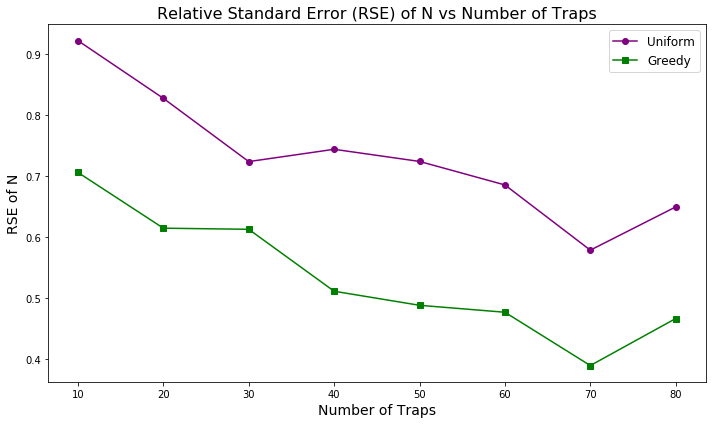

<Figure size 432x288 with 0 Axes>

In [ ]:
####### SELECTED VIA BIAS IN SAA ####################

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]


def calc_rse_and_sd(n_estimates):
    n_estimates = np.array(n_estimates)
    valid = np.isfinite(n_estimates) & (n_estimates > 0)   # avoid divide by zero
    n_estimates = n_estimates[valid]
    if n_estimates.size == 0:
        return np.nan, 0
    rse = np.std(n_estimates) / np.mean(n_estimates)
    # For spread, bootstrap standard deviation of RSE samples
    boot_rses = []
    for _ in range(1000):
        sample = np.random.choice(n_estimates, size=n_estimates.size, replace=True)
        boot_rses.append(np.std(sample) / np.mean(sample))
    spread = np.std(boot_rses)  # standard deviation as error bar size
    return rse, spread


def process_uniform_rse_spread(folder, filter_large_errors=True):
    mean_vals, spread_vals = [], []
    for n in trap_counts:
        pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, spread = calc_rse_and_sd(pooled_nestimates)
        mean_vals.append(rse)
        spread_vals.append(spread)
    return np.array(mean_vals), np.array(spread_vals)


def process_greedy_rse_spread(folder, filter_large_errors=True):
    mean_vals, spread_vals = [], []
    for n in trap_counts:
        pattern = f'SA2-*-{n}traps_test.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_nestimates = []
        for path in file_paths:
            df = pd.read_csv(path)
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_nestimates.extend(df['N_mod'].values)
        rse, spread = calc_rse_and_sd(pooled_nestimates)
        mean_vals.append(rse)
        spread_vals.append(spread)
    return np.array(mean_vals), np.array(spread_vals)


# Get RSE data with spread
uniform_rse_means, uniform_rse_spread = process_uniform_rse_spread(uniform_folder, True)
greedy_rse_means, greedy_rse_spread = process_greedy_rse_spread(greedy_folder, True)

plt.figure(figsize=(10, 6))
plt.errorbar(trap_counts, uniform_rse_means, marker='o', color='purple', label='Uniform', capsize=5)
plt.errorbar(trap_counts, greedy_rse_means, marker='s', color='green', label='Greedy', capsize=5)
plt.title('Relative Standard Error (RSE) of N vs Number of Traps', fontsize=16)
plt.xlabel('Number of Traps', fontsize=14)
plt.ylabel('RSE of N', fontsize=14)
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()
plt.savefig('marten_uniform_greedy_RSE_comparison_spread.png', dpi=300, bbox_inches='tight')


In [ ]:

folder_path = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/val_results"
pattern = os.path.join(folder_path, "SA2-*-*traps_val.csv")

results = []

for filepath in glob.glob(pattern):
    # Extract ordering numbers from filename, e.g. SA2-3-12traps_val.csv -> first_num=3, second_num=12
    basename = os.path.basename(filepath)
    match = re.match(r'SA2-(\d+)-(\d+)traps_val\.csv', basename)
    if not match:
        continue
    first_num = int(match.group(1))
    second_num = int(match.group(2))

    df = pd.read_csv(filepath)
    # Filter rows where N_abs_error <= 1000
    df_filtered = df[df['N_abs_error'] <= 1000]

    # Calculate RSE of column N_mod
    mean_val = df_filtered['N_mod'].mean()
    stddev_val = df_filtered['N_mod'].std()
    rse = (stddev_val / mean_val) * 100 if mean_val != 0 else None

    results.append({'first_num': first_num, 'second_num': second_num, 'filename': basename, 'RSE': rse})

# Create DataFrame of results and sort by first_num and second_num
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['first_num', 'second_num']).reset_index(drop=True)

results_df.to_csv('sa2_val_rse_results.csv', index=False)


In [15]:
import pandas as pd
import glob
import re
import os

folder_path = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/val_results"
pattern = os.path.join(folder_path, "SA2-*-*traps_val.csv")

all_results = []

for filepath in glob.glob(pattern):
    basename = os.path.basename(filepath)
    match = re.match(r'SA2-(\d+)-(\d+)traps_val\.csv', basename)
    if not match:
        continue
    first_num = int(match.group(1))
    second_num = int(match.group(2))

    df = pd.read_csv(filepath)
    df_filtered = df[df['N_abs_error'] <= 1000]

    mean_val = df_filtered['N_mod'].mean()
    stddev_val = df_filtered['N_mod'].std()
    rse = (stddev_val / mean_val) * 100 if mean_val != 0 else float('nan')

    all_results.append({
        'filename': basename,
        'first_num': first_num,
        'second_num': second_num,
        'RSE': rse
    })

results_df = pd.DataFrame(all_results)

# Group by second_num, then for the rows with a given second_num, select the filename with min RSE
min_rse_per_second_num = results_df.loc[results_df.groupby('second_num')['RSE'].idxmin()]

# If you want them ordered by second_num
min_rse_per_second_num = min_rse_per_second_num.sort_values('second_num').reset_index(drop=True)

print(min_rse_per_second_num[['second_num', 'filename', 'RSE']])


   second_num                filename        RSE
0          10   SA2-5-10traps_val.csv  46.813262
1          20  SA2-13-20traps_val.csv  41.312644
2          30   SA2-6-30traps_val.csv  34.978327
3          40   SA2-5-40traps_val.csv  39.197025
4          50   SA2-9-50traps_val.csv  40.475371
5          60  SA2-19-60traps_val.csv  30.821593
6          70  SA2-20-70traps_val.csv  29.355483
7          80  SA2-16-80traps_val.csv  28.197795


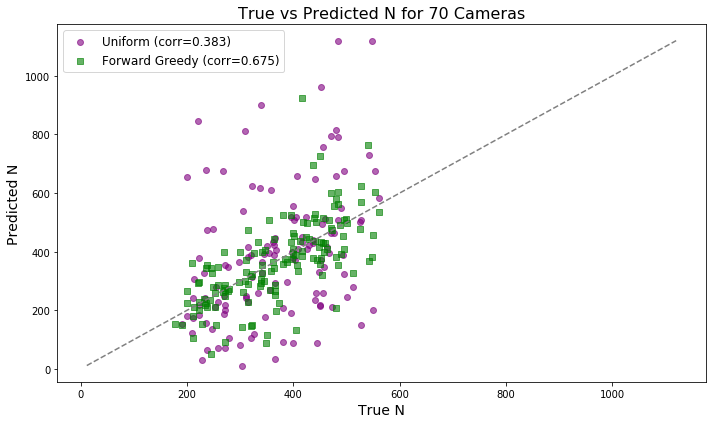

In [10]:

from scipy.stats import pearsonr

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_count_filter = 70
error_threshold = 1000

def load_filtered_data_for_trap_count(folder, trap_count, error_threshold=1000):
    all_true = []
    all_pred = []
    if 'SA2' in folder:
        pattern = f'SA2-*-{trap_count}traps_test.csv'
    else:
        pattern = f'U_{trap_count:02d}A_1km_SAA2_A.csv'
    file_paths = glob.glob(os.path.join(folder, pattern))
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        df_filtered = df[df['N_abs_error'] <= error_threshold]
        all_true.extend(df_filtered['N_true'].values)
        all_pred.extend(df_filtered['N_mod'].values)
    return np.array(all_true), np.array(all_pred)

# Load data only for 70 cameras
uniform_true, uniform_pred = load_filtered_data_for_trap_count(uniform_folder, trap_count_filter, error_threshold)
greedy_true, greedy_pred = load_filtered_data_for_trap_count(greedy_folder, trap_count_filter, error_threshold)

# Calculate Pearson correlation
r_uniform, _ = pearsonr(uniform_true, uniform_pred) if len(uniform_true) > 1 else (np.nan, np.nan)
r_greedy, _ = pearsonr(greedy_true, greedy_pred) if len(greedy_true) > 1 else (np.nan, np.nan)


# Plot on same figure
plt.figure(figsize=(10, 6))
plt.scatter(uniform_true, uniform_pred, color='purple', alpha=0.6, label=f'Uniform (corr={r_uniform:.3f})', marker='o')
plt.scatter(greedy_true, greedy_pred, color='green', alpha=0.6, label=f'Forward Greedy (corr={r_greedy:.3f})', marker='s')
plt.xlabel('True N', fontsize=14)
plt.ylabel('Predicted N', fontsize=14)
plt.title(f'True vs Predicted N for {trap_count_filter} Cameras', fontsize=16)
plt.legend(fontsize=12)

# After plotting your scatter points but before plt.tight_layout() and plt.show()
min_axis = min(uniform_true.min(), uniform_pred.min(), greedy_true.min(), greedy_pred.min())
max_axis = max(uniform_true.max(), uniform_pred.max(), greedy_true.max(), greedy_pred.max())
plt.plot([min_axis, max_axis], [min_axis, max_axis], color='gray', linestyle='--', label='y = x')

# plt.grid(True)
plt.tight_layout()
plt.show()


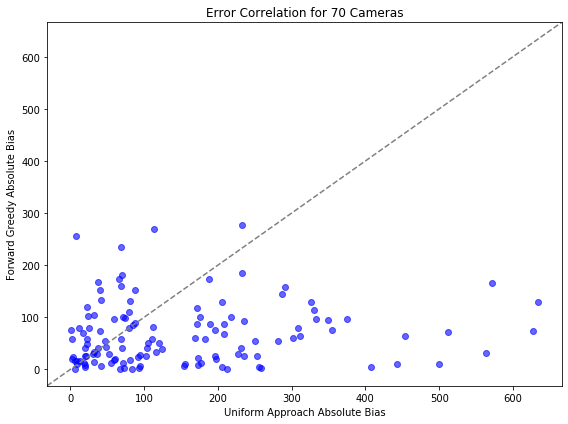

In [29]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_count_filter = 70
error_threshold = 1000

def load_data_with_draw(folder, trap_count, error_threshold=1000):
    if 'SA2' in folder:
        pattern = f'SA2-*-{trap_count}traps_test.csv'
    else:
        pattern = f'U_{trap_count:02d}A_1km_SAA2_A.csv'
    file_paths = glob.glob(os.path.join(folder, pattern))
    dfs = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        df_filtered = df[df['N_abs_error'] <= error_threshold]
        dfs.append(df_filtered)
    if dfs:
        return pd.concat(dfs).reset_index(drop=True)
    else:
        return pd.DataFrame()

# Load filtered dataframes for uniform and greedy
df_uniform = load_data_with_draw(uniform_folder, trap_count_filter, error_threshold)
df_greedy = load_data_with_draw(greedy_folder, trap_count_filter, error_threshold)

# Merge dataframes on 'Draw' to align scenarios exactly
df_merged = pd.merge(df_uniform[['Draw', 'N_abs_error']], df_greedy[['Draw', 'N_abs_error']],
                     on='Draw', suffixes=('_uniform', '_greedy'))

# Pearson correlation of errors between uniform and greedy
r_error, _ = pearsonr(df_merged['N_abs_error_uniform'], df_merged['N_abs_error_greedy']) if len(df_merged) > 1 else (np.nan, np.nan)

# Determine the axis limits for identical scaling
combined_min = min(df_merged['N_abs_error_uniform'].min(), df_merged['N_abs_error_greedy'].min())
combined_max = max(df_merged['N_abs_error_uniform'].max(), df_merged['N_abs_error_greedy'].max())
margin = (combined_max - combined_min) * 0.05  # 5% margin
axis_min = combined_min - margin
axis_max = combined_max + margin

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_merged['N_abs_error_uniform'], df_merged['N_abs_error_greedy'], color='blue', alpha=0.6)
plt.plot([axis_min, axis_max], [axis_min, axis_max], color='gray', linestyle='--', label='y = x')
plt.xlabel('Uniform Approach Absolute Bias')
plt.ylabel('Forward Greedy Absolute Bias')
plt.title(f'Error Correlation for {trap_count_filter} Cameras')
# plt.legend()
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
# plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
import os
import glob
import pandas as pd

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_count_filter = 70
error_threshold = 1000

# Function to compute mean errors for specified metrics
def compute_mean_errors(folder, trap_count, error_threshold=1000):
    metrics = ['N_abs_error', 'beta1_abs_error', 'beta2_abs_error', 'sigma_abs_error', 'g0_abs_error']
    totals = {metric: 0.0 for metric in metrics}
    count = 0

    if 'SA2' in folder:
        pattern = f'SA2-*-{trap_count}traps_test.csv'
    else:
        pattern = f'U_{trap_count:02d}A_1km_SAA2_A.csv'
    file_paths = glob.glob(os.path.join(folder, pattern))
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        df_filtered = df[df['N_abs_error'] <= error_threshold]
        count += len(df_filtered)
        for metric in metrics:
            totals[metric] += df_filtered[metric].sum()

    # Compute mean for each metric
    means = {metric: totals[metric] / count if count > 0 else np.nan for metric in metrics}
    return means

# Compute for uniform
uniform_means = compute_mean_errors(uniform_folder, trap_count_filter, error_threshold)

# Compute for greedy
greedy_means = compute_mean_errors(greedy_folder, trap_count_filter, error_threshold)

# Build results table
results_df = pd.DataFrame({
    'Metric': ['N', 'beta1', 'beta2', 'sigma', 'g0'],
    'Uniform': [
        uniform_means['N_abs_error'],
        uniform_means['beta1_abs_error'],
        uniform_means['beta2_abs_error'],
        uniform_means['sigma_abs_error'],
        uniform_means['g0_abs_error']
    ],
    'Forward Greedy': [
        greedy_means['N_abs_error'],
        greedy_means['beta1_abs_error'],
        greedy_means['beta2_abs_error'],
        greedy_means['sigma_abs_error'],
        greedy_means['g0_abs_error']
    ]
})

print(results_df)


  Metric     Uniform  Forward Greedy
0      N  151.983614       73.761040
1  beta1    0.644188        0.766715
2  beta2    0.593422        0.475763
3  sigma  141.527847       79.900484
4     g0    0.106487        0.112761


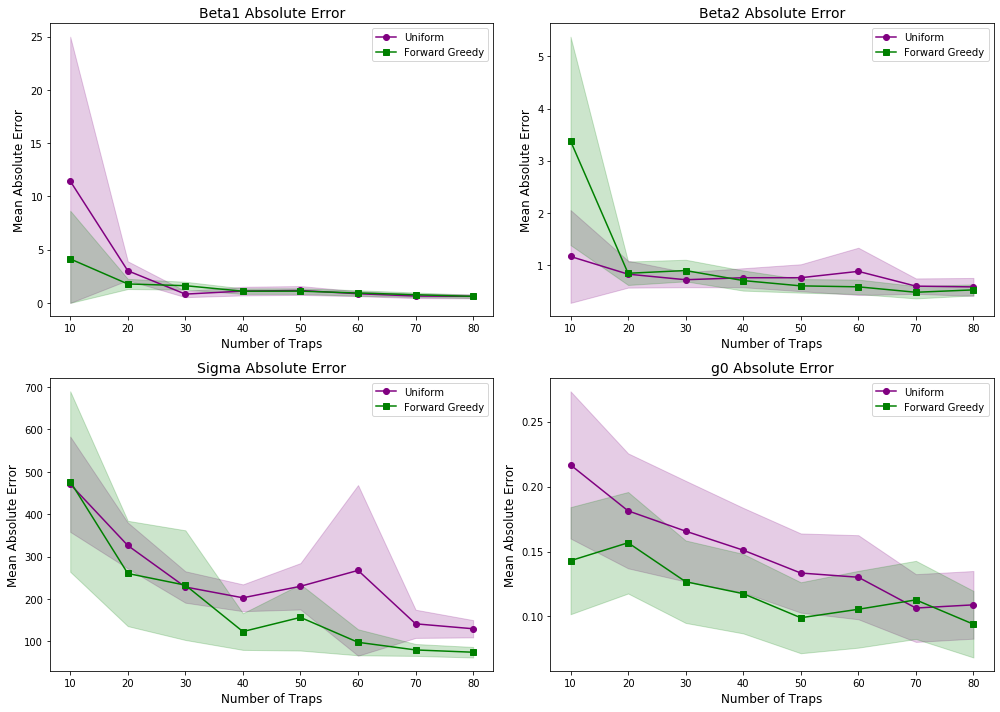

In [ ]:
######## SELECTED VIA BIAS IN SAA ####################

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

metrics_info = {
    'beta1_abs_error': 'Beta1 Absolute Error',
    'beta2_abs_error': 'Beta2 Absolute Error',
    'sigma_abs_error': 'Sigma Absolute Error',
    'g0_abs_error': 'g0 Absolute Error'
}

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

def process_data(folder, metric, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        if folder == uniform_folder:
            pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        else:
            pattern = f'SA2-*-{n}traps_test.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            # Use N_abs_error threshold to filter rows consistently
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df[metric].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Prepare plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (metric, title) in enumerate(metrics_info.items()):
    uniform_means, uniform_cis = process_data(uniform_folder, metric, True)
    greedy_means, greedy_cis = process_data(greedy_folder, metric, True)

    ax = axes[i]
    ax.plot(trap_counts, uniform_means, marker='o', color='purple', label='Uniform')
    ax.fill_between(
        trap_counts,
        np.maximum(uniform_means - uniform_cis, 0),
        uniform_means + uniform_cis,
        color='purple', alpha=0.2
    )
    ax.plot(trap_counts, greedy_means, marker='s', color='green', label='Forward Greedy')
    ax.fill_between(
        trap_counts,
        np.maximum(greedy_means - greedy_cis, 0),
        greedy_means + greedy_cis,
        color='green', alpha=0.2
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Number of Traps', fontsize=12)
    ax.set_ylabel('Mean Absolute Error', fontsize=12)
    ax.legend()
    ax.grid(False)

plt.tight_layout()
plt.show()


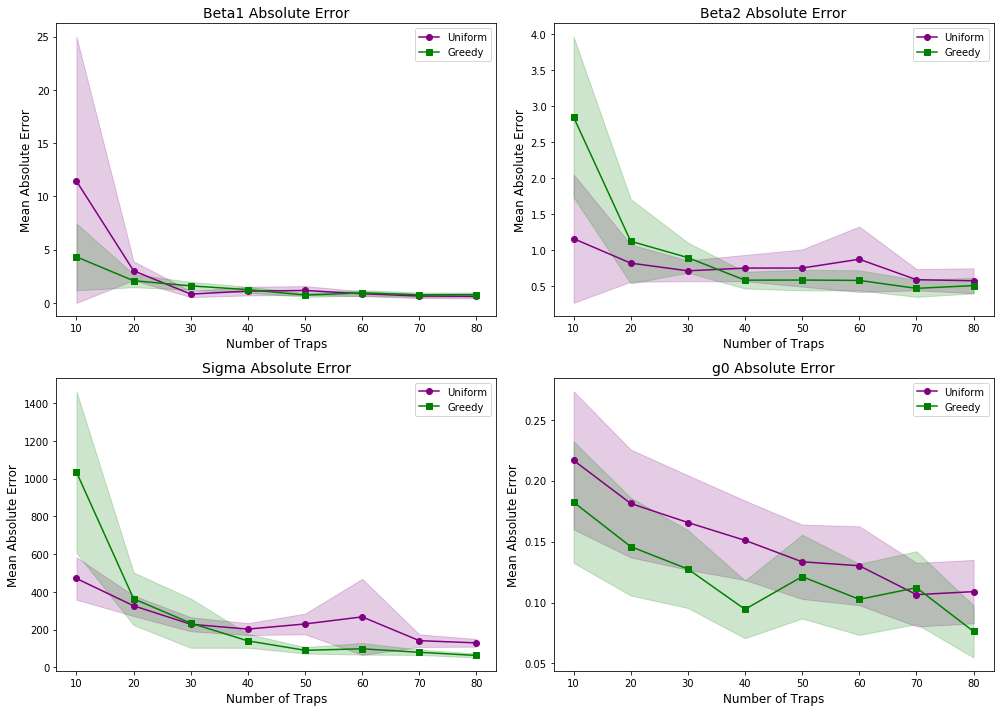


Average Mean Absolute Error across all budgets for each metric:
Beta1 Absolute Error:
  Uniform: 2.4581
  Greedy : 1.5567
Beta2 Absolute Error:
  Uniform: 0.7825
  Greedy : 0.9521
Sigma Absolute Error:
  Uniform: 249.6519
  Greedy : 263.0347
g0 Absolute Error:
  Uniform: 0.1492
  Greedy : 0.1203

Average Mean Absolute Error across all budgets (excluding 10 traps) for each metric:
Beta1 Absolute Error:
  Uniform: 1.1757
  Greedy : 1.1620
Beta2 Absolute Error:
  Uniform: 0.7282
  Greedy : 0.6813
Sigma Absolute Error:
  Uniform: 218.0653
  Greedy : 152.9005
g0 Absolute Error:
  Uniform: 0.1396
  Greedy : 0.1115


In [51]:
###### SELECTED VIA RSE IN SAA ####################

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA2_Marten'
greedy_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/test_results/RSE'
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

metrics_info = {
    'beta1_abs_error': 'Beta1 Absolute Error',
    'beta2_abs_error': 'Beta2 Absolute Error',
    'sigma_abs_error': 'Sigma Absolute Error',
    'g0_abs_error': 'g0 Absolute Error'
}

def calc_95ci(values):
    values = np.array(values)
    n = len(values)
    if n == 0:
        return np.nan, 0
    mean_val = np.mean(values)
    if n == 1:
        return mean_val, 0
    sem = stats.sem(values)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci = t_crit * sem
    return mean_val, ci

def process_data(folder, metric, filter_large_errors=True):
    mean_vals, ci_vals = [], []
    for n in trap_counts:
        if folder == uniform_folder:
            pattern = f'U_{n:02d}A_1km_SAA2_A.csv'
        else:
            pattern = f'SA2-*-{n}traps_test_RSE.csv'
        file_paths = glob.glob(os.path.join(folder, pattern))
        pooled_errors = []
        for path in file_paths:
            df = pd.read_csv(path)
            # Use N_abs_error threshold to filter rows consistently
            if filter_large_errors:
                df = df[df['N_abs_error'] <= 1000]
            pooled_errors.extend(df[metric].values)
        mean_val, ci = calc_95ci(pooled_errors)
        mean_vals.append(mean_val)
        ci_vals.append(ci)
    return np.array(mean_vals), np.array(ci_vals)

# Prepare plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (metric, title) in enumerate(metrics_info.items()):
    uniform_means, uniform_cis = process_data(uniform_folder, metric, True)
    greedy_means, greedy_cis = process_data(greedy_folder, metric, True)

    ax = axes[i]
    ax.plot(trap_counts, uniform_means, marker='o', color='purple', label='Uniform')
    ax.fill_between(
        trap_counts,
        np.maximum(uniform_means - uniform_cis, 0),
        uniform_means + uniform_cis,
        color='purple', alpha=0.2
    )
    ax.plot(trap_counts, greedy_means, marker='s', color='green', label='Greedy')
    ax.fill_between(
        trap_counts,
        np.maximum(greedy_means - greedy_cis, 0),
        greedy_means + greedy_cis,
        color='green', alpha=0.2
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Number of Traps', fontsize=12)
    ax.set_ylabel('Mean Absolute Error', fontsize=12)
    ax.legend()
    ax.grid(False)

plt.tight_layout()
plt.show()

# Initialize dictionaries to hold means for averaging later
uniform_means_dict = {}
greedy_means_dict = {}

# Re-run processing to also store means for averaging
for metric in metrics_info.keys():
    uniform_means, uniform_cis = process_data(uniform_folder, metric, True)
    greedy_means, greedy_cis = process_data(greedy_folder, metric, True)
    uniform_means_dict[metric] = uniform_means
    greedy_means_dict[metric] = greedy_means

print("\nAverage Mean Absolute Error across all budgets for each metric:")
for metric, title in metrics_info.items():
    avg_uniform = np.mean(uniform_means_dict[metric])
    avg_greedy = np.mean(greedy_means_dict[metric])
    print(f"{title}:")
    print(f"  Uniform: {avg_uniform:.4f}")
    print(f"  Greedy : {avg_greedy:.4f}")

print("\nAverage Mean Absolute Error across all budgets (excluding 10 traps) for each metric:")
for metric, title in metrics_info.items():
    avg_uniform = np.mean(uniform_means_dict[metric][1:])  # skip first element
    avg_greedy = np.mean(greedy_means_dict[metric][1:])    # skip first element
    print(f"{title}:")
    print(f"  Uniform: {avg_uniform:.4f}")
    print(f"  Greedy : {avg_greedy:.4f}")





In [4]:
import os
import glob
import pandas as pd
import numpy as np

# Folder containing the SA2 results
folder_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/val_results'

# Search pattern for expected filenames
file_paths = glob.glob(os.path.join(folder_path, 'SA2-*-*traps_val.csv'))

records = []

for path in file_paths:
    filename = os.path.basename(path)
    # Expected format: SA2-#-##traps_val.csv
    parts = filename.replace('.csv', '').split('-')
    
    # Extract run number and trap count
    run_id = parts[1]
    trap_str = parts[2].replace('traps_val', '')
    num_traps = int(trap_str)
    
    # Load the dataset
    df = pd.read_csv(path)
    if 'N_abs_error' not in df.columns:
        continue
    
    # Filter and compute mean error
    df_filtered = df[df['N_abs_error'] <= 1000]
    mean_error = np.mean(df_filtered['N_abs_error']) if len(df_filtered) > 0 else np.nan
    
    # One summary row per file
    records.append([f'SA2-{run_id}', num_traps, mean_error])

# Build summary DataFrame with 160 rows (20 runs × 8 trap levels)
output_df = pd.DataFrame(records, columns=['Run_ID', 'Num_Traps', 'Mean_Filtered_N_abs_error'])

# Save output to same directory
output_path = os.path.join(folder_path, 'SA2_filtered_mean_errors.csv')
output_df.to_csv(output_path, index=False)

print(f'Summary saved to {output_path} with {len(output_df)} rows (expected 160).')


Summary saved to /Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA2/val_results/SA2_filtered_mean_errors.csv with 159 rows (expected 160).


### IP Unique Configurations

In [4]:
# import os
# import pandas as pd

# base_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten (A)"
# budgets = [10, 20, 30, 40, 50, 60, 70, 80]
# param_draws = [6, 7, 8, 10, 11, 16, 17, 18, 20, 23, 25, 26, 31, 34, 38, 43, 46, 47, 57, 58, 60, 61, 64, 67, 68, 69, 73, 
#       74, 76, 77, 78, 79, 80, 83, 85, 91, 93, 94, 98, 102, 105, 109, 110, 112, 114, 115, 119, 120, 125, 127, 130, 
#       145, 148, 149, 153, 155, 158, 164, 165, 166, 174, 176, 180, 181, 183, 186, 187, 193, 194, 195, 197, 204, 212, 
#       216, 219, 222, 225, 227, 230, 231, 232, 233, 234, 235, 238, 239, 240, 250, 251, 257, 267, 275, 279, 282, 283, 
#       287, 289, 290, 296, 298]

# print("Computing number of unique configurations for each budget:")

# for budget in budgets:
#     config_set = set()
#     budget_dir = os.path.join(base_dir, f"Budget = {budget}")
#     for param_id in param_draws:
#         selected_csv = os.path.join(
#             budget_dir,
#             f"IP-selected_ids-budget{budget}-param{param_id}.csv"
#         )
#         if not os.path.exists(selected_csv):
#             print(f"Warning: {selected_csv} does not exist, skipping.")
#             continue
#         df = pd.read_csv(selected_csv)
#         # Use frozenset to ensure configuration is counted regardless of order
#         config_set.add(frozenset(df['Trap_index'].tolist()))
#     print(f"Budget {budget}: {len(config_set)} unique configurations")

import os
import pandas as pd

base_dir = "/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Integer Programming/Marten (A)"
budgets = [10, 20, 30, 40, 50, 60, 70, 80]

print("Computing number of unique configurations for each budget:")

for budget in budgets:
    config_set = set()
    budget_dir = os.path.join(base_dir, f"Budget = {budget}")
    
    # Check if the budget folder exists
    if not os.path.exists(budget_dir):
        print(f"Warning: {budget_dir} does not exist, skipping.")
        continue

    # List all Param folders inside this budget folder
    param_folders = [f.path for f in os.scandir(budget_dir) if f.is_dir()]

    for param_folder in param_folders:
        # Look for all selected_ids files inside this Param folder
        for file in os.listdir(param_folder):
            if file.startswith("IP-selected_ids") and file.endswith(".csv"):
                selected_csv = os.path.join(param_folder, file)
                df = pd.read_csv(selected_csv)
                config_set.add(frozenset(df['Trap_index'].tolist()))

    print(f"Budget {budget}: {len(config_set)} unique configurations")


Computing number of unique configurations for each budget:
Budget 10: 90 unique configurations
Budget 20: 97 unique configurations
Budget 30: 99 unique configurations
Budget 40: 97 unique configurations
Budget 50: 97 unique configurations
Budget 60: 100 unique configurations
Budget 70: 99 unique configurations
Budget 80: 100 unique configurations


### Genetic Algorithm

In [31]:
import pandas as pd
from pathlib import Path
import re

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4")

# Budgets to process
budgets = [10, 20, 30, 40]
all_results = []

# Loop through budgets
for budget in budgets:
    val_dir = BASE_DIR / f"Budget_{budget}" / "Validation Results"
    
    if not val_dir.exists():
        print(f"Budget_{budget} Validation Results directory not found")
        continue
    
    # print(f"\nProcessing Budget_{budget}...")
    budget_results = []
    
    # Process all CSV files in Validation Results folder
    for csv_path in val_dir.glob("*.csv"):
        df = pd.read_csv(csv_path)
        
        # Filter out big errors (N_abs_error > 1000)
        df_filtered = df[df['N_abs_error'] <= 1000]
        
        if len(df_filtered) == 0:
            print(f"  No valid data in {csv_path.name} (all errors > 1000)")
            continue
        
        # Calculate metrics - RSE as percentage
        mean_n_error = df_filtered['N_abs_error'].mean()
        std_n_error = df_filtered['N_abs_error'].std()
        rse_n = (std_n_error / mean_n_error) * 100 if mean_n_error != 0 else float('nan')
        
        # Extract SA number from filename
        sa_match = re.search(r'SA(\d+)', csv_path.name)
        sa_num = int(sa_match.group(1)) if sa_match else 0
        
        budget_results.append({
            'budget': budget,
            'sa_num': sa_num,
            'filename': csv_path.name,
            'n_valid_rows': len(df_filtered),
            'mean_N_error': mean_n_error,
            'RSE_N': rse_n
        })
    
    all_results.extend(budget_results)

# Create singular combined results DataFrame with budget column
results_df = pd.DataFrame(all_results)

# Sort by SA# first, then by budget
results_df = results_df.sort_values(['sa_num', 'budget']).reset_index(drop=True)

# Display the single DataFrame
# print("Combined Validation Results (sorted by SA#, then budget):")
# print(results_df[['sa_num', 'budget', 'filename', 'n_valid_rows', 'mean_N_error', 'RSE_N']].round(2))
# print(f"\nShape: {results_df.shape}")

results_df
results_df.to_csv("genetic_algo_val_secr_runs.csv")


In [20]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4")

# Process all budget folders
for budget_dir in BASE_DIR.glob("Budget_*"):
    if not budget_dir.is_dir():
        continue
    
    budget_id = budget_dir.name
    unselected_dir = budget_dir / "Unselected_traps"  # assuming unselected_traps are here too
    
    # Create excluded_traps subfolder
    excluded_dir = budget_dir / "excluded_traps"
    excluded_dir.mkdir(exist_ok=True)
    
    print(f"Processing {budget_dir.name}...")
    
    # Find unselected_traps files (adjust pattern if different)
    for csv_path in unselected_dir.glob("unselected_traps*.csv"):
        # Read CSV, skip first empty column, get Trap_index
        df = pd.read_csv(csv_path)
        excluded_ids = sorted(df["Trap_index"].astype(int))
        
        # Write as simple text file with one ID per line
        txt_path = excluded_dir / f"{csv_path.stem}_excluded.txt"
        with open(txt_path, 'w') as f:
            for trap_id in excluded_ids:
                f.write(f"{trap_id}\n")
        
        print(f"  Created {txt_path.name}: {len(excluded_ids)} traps")

print("Done! All excluded_traps files created.")


Processing Budget_70...
  Created unselected_traps_SA17_excluded.txt: 1015 traps
  Created unselected_traps_SA16_excluded.txt: 1015 traps
  Created unselected_traps_SA14_excluded.txt: 1015 traps
  Created unselected_traps_SA15_excluded.txt: 1015 traps
  Created unselected_traps_SA11_excluded.txt: 1015 traps
  Created unselected_traps_SA10_excluded.txt: 1015 traps
  Created unselected_traps_SA12_excluded.txt: 1015 traps
  Created unselected_traps_SA13_excluded.txt: 1015 traps
  Created unselected_traps_SA9_excluded.txt: 1015 traps
  Created unselected_traps_SA8_excluded.txt: 1015 traps
  Created unselected_traps_SA5_excluded.txt: 1015 traps
  Created unselected_traps_SA4_excluded.txt: 1015 traps
  Created unselected_traps_SA6_excluded.txt: 1015 traps
  Created unselected_traps_SA7_excluded.txt: 1015 traps
  Created unselected_traps_SA3_excluded.txt: 1015 traps
  Created unselected_traps_SA2_excluded.txt: 1015 traps
  Created unselected_traps_SA1_excluded.txt: 1015 traps
  Created unsele

In [21]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4")

records = []

# loop over all budget folders (Budget_10 to Budget_80)
for budget_dir in BASE_DIR.glob("Budget_*"):
    if not budget_dir.is_dir():
        continue

    budget_id = int(budget_dir.name.split("_")[1])

    selected_dir = budget_dir / "Selected_traps"
    if not selected_dir.exists():
        continue

    # loop over all selected_traps_SA*.csv files (SA1 to SA20)
    for csv_path in selected_dir.glob("selected_traps_SA*.csv"):
        sa_id = csv_path.name  # Use filename as identifier (SA1, SA2, etc.)
        
        df = pd.read_csv(csv_path)

        # configuration is the sorted tuple of unique Trap_index values
        config = tuple(sorted(df["Trap_index"].unique()))

        records.append({
            "budget": budget_id,
            "sa_id": sa_id,
            "config": config,
        })

# dataframe with one row per file
df_configs = pd.DataFrame(records)

# group by budget and configuration, count occurrences
unique_configs = (
    df_configs
    .groupby(["budget", "config"], as_index=False)
    .agg(n_occurrences=("sa_id", "size"))
    .groupby("budget", as_index=False)
    .agg(n_unique_configs=("config", "size"))
)

unique_configs


,budget,n_unique_configs
0,10,17
1,20,20
2,30,20
3,40,20
4,50,20
5,60,20
6,70,20
7,80,2


In [5]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Genetic Algorithm/Objective 4")

records = []

# Filter for budget 10 only
budget_target = 10
budget_dir = BASE_DIR / f"Budget_{budget_target}"
if not budget_dir.exists():
    print(f"Budget_{budget_target} directory not found")
else:
    selected_dir = budget_dir / "Selected_traps"
    if not selected_dir.exists():
        print("Selected_traps directory not found")
    else:
        # loop over all selected_traps_SA*.csv files (SA1 to SA20)
        for csv_path in selected_dir.glob("selected_traps_SA*.csv"):
            sa_id = csv_path.name
            
            df = pd.read_csv(csv_path)
            config = tuple(sorted(df["Trap_index"].unique()))
            
            records.append({
                "file": sa_id,
                "config": config,
            })

# Create dataframe and group by config
df_configs = pd.DataFrame(records)

# Get unique configurations with their corresponding files
config_files = (
    df_configs
    .groupby("config")["file"]
    .apply(list)
    .reset_index()
)

# Print results
print(f"Unique configurations for Budget_{budget_target}:")
print(f"Total unique configs: {len(config_files)} out of 20 files\n")

for idx, row in config_files.iterrows():
    config_str = str(row["config"])[:100] + "..." if len(str(row["config"])) > 100 else str(row["config"])
    files_str = ", ".join(row["file"])
    print(f"Config {idx+1}: {config_str}")
    print(f"  Files: {files_str}")
    print()


Unique configurations for Budget_10:
Total unique configs: 17 out of 20 files

Config 1: (24, 98, 99, 133, 134, 764, 797, 798, 833, 934)
  Files: selected_traps_SA17.csv

Config 2: (27, 62, 63, 98, 99, 139, 194, 659, 798, 899)
  Files: selected_traps_SA19.csv

Config 3: (62, 63, 98, 139, 684, 718, 719, 728, 763, 899)
  Files: selected_traps_SA8.csv

Config 4: (62, 63, 99, 134, 138, 728, 763, 874, 875, 899)
  Files: selected_traps_SA18.csv

Config 5: (98, 138, 649, 683, 684, 687, 688, 722, 723, 728)
  Files: selected_traps_SA11.csv

Config 6: (98, 686, 687, 688, 721, 722, 723, 840, 874, 875)
  Files: selected_traps_SA20.csv

Config 7: (646, 684, 687, 688, 722, 839, 840, 874, 875, 1049)
  Files: selected_traps_SA16.csv

Config 8: (649, 683, 684, 685, 686, 687, 839, 840, 874, 875)
  Files: selected_traps_SA10.csv

Config 9: (649, 683, 684, 685, 719, 720, 839, 840, 874, 875)
  Files: selected_traps_SA6.csv

Config 10: (649, 683, 684, 687, 688, 839, 840, 874, 875, 1049)
  Files: selected_tr

### Prob Cap Exploration

In [13]:
param_draws = [6, 7, 8, 10, 11, 16, 17, 18, 20, 23, 25, 26, 31, 34, 38, 43, 46, 47, 57, 58, 60, 
              61, 64, 67, 68, 69, 73, 74, 76, 77, 78, 79, 80, 83, 85, 91, 93, 94, 98, 102, 105, 109, 110, 112, 
              114, 115, 119, 120, 125, 127, 130, 145, 148, 149, 153, 155, 158, 164, 165, 166, 174, 176, 180, 181, 
              183, 186, 187, 193, 194, 195, 197, 204, 212, 216, 219, 222, 225, 227, 230, 231, 232, 233, 234, 235, 
              238, 239, 240, 250, 251, 257, 267, 275, 279, 282, 283, 287, 289, 290, 296, 298]
K = 5 

# Read in activity centers
ac_coords = pyreadr.read_r('./full_grid_1km/10-3 data (Marten)/500m_mask_marten.RDS')
ac_df = next(iter(ac_coords.values()))
ac_coords_list = ac_df[['x', 'y']].values

# Read in candidate trap locations
trap_coords = pd.read_csv('./full_grid_1km/10-3 data (Marten)/1000m_trap_grid_marten.csv').drop(columns=['Unnamed: 0'])
trap_coords_list = trap_coords[['x', 'y']].values
num_traps = len(trap_coords_list)

# Calculate distances between all candidate traps and activity centers
traps = trap_coords_list[:, np.newaxis, :]   
centers = ac_coords_list[np.newaxis, :, :]   
distances = np.linalg.norm(traps - centers, axis=2) 

# Extract parameter draws
params = pd.read_csv('./full_grid_1km/10-3 data (Marten)/param_values_for_each_draw300_marten.csv')


num_draws = len(param_draws)
num_cells = distances.shape[1]

prob_cap_all = np.empty((num_draws, num_traps, num_cells), dtype=float)

for idx, param_id in enumerate(param_draws):
    param_row = params.iloc[param_id - 1]  # rows are 1-indexed in your original code
    g0_val = param_row['g0']
    sigma_val = param_row['sigma']

    alpha1 = 1.0 / (2.0 * sigma_val**2)
    prob_cap = g0_val * np.exp(-alpha1 * (distances**2))  # (num_traps, num_cells)

    prob_cap_all[idx, :, :] = prob_cap

# ----------------------------
# 3. Summarize distribution
# ----------------------------

flat_probs = prob_cap_all.ravel()

print("=== Capture probability distribution over all draws, traps, and cells ===")
print(f"Global min: {flat_probs.min():.8f}")
print(f"Global max: {flat_probs.max():.8f}")
print(f"Mean:       {flat_probs.mean():.8f}")
print(f"Std:        {flat_probs.std():.8f}")

percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
print("\nPercentiles:")
for q in percentiles:
    val = np.percentile(flat_probs, q)
    print(f"{q:3d}th: {val:.8f}")

# Per-draw min/max (first few draws)
draw_mins = prob_cap_all.min(axis=(1, 2))
draw_maxs = prob_cap_all.max(axis=(1, 2))

print("\nPer-draw min/max (first 10 draws):")
for i, param_id in enumerate(param_draws[:10]):
    print(f"Draw id {param_id:3d}: min={draw_mins[i]:.8f}, max={draw_maxs[i]:.8f}")


# count how many probabilities end up being 0
zero_count = np.sum(flat_probs == 0.0000000)
total_count = flat_probs.size
print(f"\nNumber of zero probabilities: {zero_count} out of {total_count} ({(zero_count/total_count)*100:.6f}%)")



print(f"Exact zeros: {(zero_count/total_count)*100:.1f}%")
print(f"Values <= 1e-10: {np.sum(flat_probs <= 1e-10)/total_count*100:.1f}%")
print(f"Median exact: {np.median(flat_probs):.8f}")


=== Capture probability distribution over all draws, traps, and cells ===
Global min: 0.00000000
Global max: 0.44478348
Mean:       0.00048912
Std:        0.00915241

Percentiles:
  0th: 0.00000000
  1th: 0.00000000
  5th: 0.00000000
 25th: 0.00000000
 50th: 0.00000000
 75th: 0.00000000
 95th: 0.00000000
 99th: 0.00105149
100th: 0.44478348

Per-draw min/max (first 10 draws):
Draw id   6: min=0.00000000, max=0.37792271
Draw id   7: min=0.00000000, max=0.21456407
Draw id   8: min=0.00000000, max=0.05613988
Draw id  10: min=0.00000000, max=0.23814318
Draw id  11: min=0.00000000, max=0.20812173
Draw id  16: min=0.00000000, max=0.32308868
Draw id  17: min=0.00000000, max=0.01761649
Draw id  18: min=0.00000000, max=0.17999162
Draw id  20: min=0.00000000, max=0.23213923
Draw id  23: min=0.00000000, max=0.19935217

Number of zero probabilities: 209619570 out of 575918000 (36.397468%)
Exact zeros: 36.4%
Values <= 1e-10: 96.1%
Median exact: 0.00000000


Fraction of trap–cell pairs > threshold: 0.001544837980406933
Fraction of cells active: 0.9193669932177845
active_cells shape: (5308,)


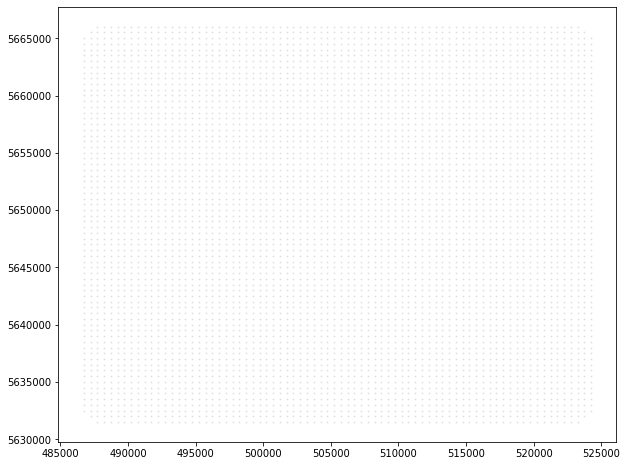

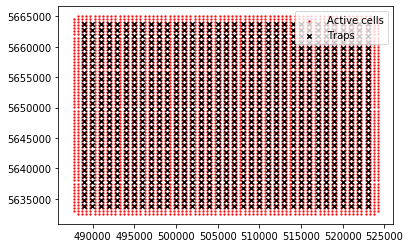

No handles with labels found to put in legend.


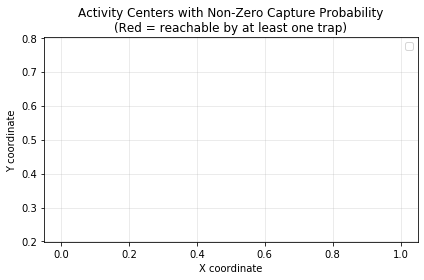

Active cells: 4880 out of 5308 total (91.9%)


In [40]:
threshold = 0.1

non_zero_mask = np.any(prob_cap_all > threshold, axis=0)   # (num_traps, num_cells)
active_cells = np.any(non_zero_mask, axis=0)               # (num_cells,)

print("Fraction of trap–cell pairs > threshold:",
      np.mean(prob_cap_all > threshold))
print("Fraction of cells active:", np.mean(active_cells))
print("active_cells shape:", active_cells.shape)


# Plot activity centers (grid cells)
plt.figure(figsize=(10, 8))

# Plot ALL activity centers as faint gray points
plt.scatter(ac_coords_list[:, 0], ac_coords_list[:, 1], 
           c='lightgray', s=1, alpha=0.5, label='All grid cells')

# Highlight ACTIVE cells (those with non-zero p_ij for at least one trap) in red

active_coords = ac_coords_list[active_cells]

plt.figure()
plt.scatter(active_coords[:, 0], active_coords[:, 1],
            c='red', s=2, alpha=0.8, label='Active cells')
plt.scatter(trap_coords_list[:, 0], trap_coords_list[:, 1],
            c='black', s=20, marker='x', label='Traps')
plt.legend()
plt.show()



# active_coords = ac_coords_list[active_cells]
# plt.scatter(active_coords[:, 0], active_coords[:, 1], 
#            c='red', s=2, alpha=0.8, label='Cells with non-zero p_ij')

# # Plot trap locations as black X's
# plt.scatter(trap_coords_list[:, 0], trap_coords_list[:, 1], 
#            c='black', s=20, marker='X', linewidth=1, label='Trap locations')

plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Activity Centers with Non-Zero Capture Probability\n(Red = reachable by at least one trap)')
plt.legend()
plt.axis('equal')  # Equal aspect ratio for map-like view
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Active cells: {np.sum(active_cells)} out of {len(ac_coords_list)} total ({100*np.sum(active_cells)/len(ac_coords_list):.1f}%)")


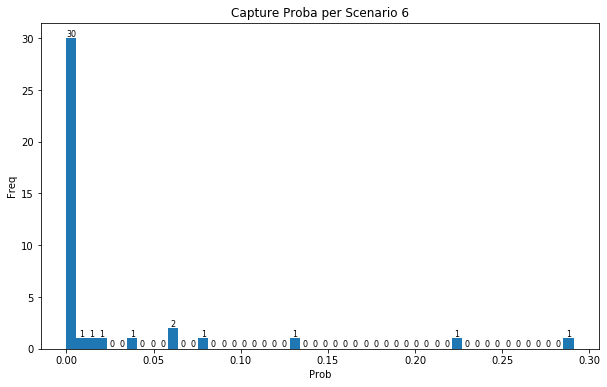

In [67]:
# for the first draw, output a plot showing the distribution of probabilties
# remove prob < 0.5

draw_idx = 0  
prob_cap_draw = prob_cap_all[draw_idx, :, 2500] 
filtered_prob_cap_draw = prob_cap_draw[prob_cap_draw > 0.0000005]

plt.figure(figsize=(10, 6))
plt.hist(filtered_prob_cap_draw.ravel(), bins=50)
plt.xlabel('Prob')
plt.ylabel('Freq')
plt.title(f'Capture Proba per Scenario {param_draws[draw_idx]}')
# label bars with y axis value
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width() / 2, p.get_height()), 
                       ha='center', va='bottom', fontsize=8)
plt.show()

In [52]:
prob_cap_all.shape

(100, 1085, 5308)

In [53]:
1085*5308

5759180

KeyboardInterrupt: 

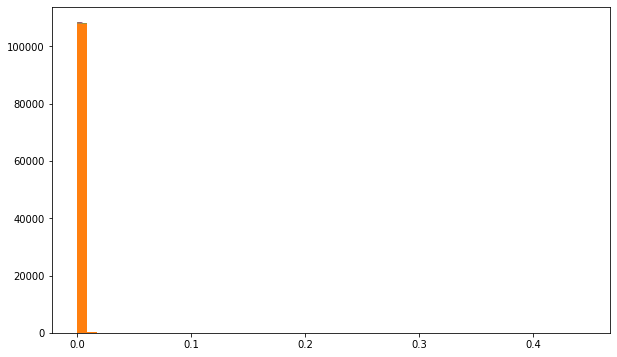

In [42]:
# for each activity center, show the distribution of probabilities in a graph
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for cell_idx in range(num_cells):
    cell_probs = prob_cap_all[:, :, cell_idx].ravel()
    plt.hist(cell_probs, bins=50, alpha=0.3, label=f'Cell {cell_idx+1}')

plt.xlabel('Capture Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Capture Probabilities per Activity Center')
plt.legend()
plt.show()

# run this for just one activity center to start
# import numpy as np
# cell_idx = 0  # first activity center
# cell_probs = prob_cap_all[:, :, cell_idx].ravel()
# plt.figure(figsize=(8, 5))
# plt.hist(cell_probs, bins=50, color='blue', alpha=0.7)
# plt.xlabel('Capture Probability')
# plt.ylabel('Frequency')
# plt.title(f'Distribution of Capture Probabilities for Activity Center {cell_idx+1}')
# plt.grid(True)
# plt.show()

### Sample Average Approximation

In [35]:
#randomly select 3 sets of numbers without replacement. First, randomly select 100 numbers 1 to 300. Then, select a random 50 of the remaining 200. Then, output the remaining into the third set of 150. 
# import numpy as np
# np.random.seed(42)  # For reproducibility
# all_numbers = np.arange(1, 301)
# set1 = np.random.choice(all_numbers, size=100, replace=False)
# remaining_after_set1 = np.setdiff1d(all_numbers, set1)
# set2 = np.random.choice(remaining_after_set1, size=50, replace=False)
# set3 = np.setdiff1d(remaining_after_set1, set2)

# print("Set 1 (100 numbers):", sorted(set1))
# print("Set 2 (50 numbers):", sorted(set2))
# print("Set 3 (150 numbers):", sorted(set3))

# within set 1, randomly select 10 numbers, 20 times in python
import numpy as np
np.random.seed(42)  # For reproducibility
set1 = set1
subsets = []
for _ in range(20):
    subset = np.random.choice(set1, size=10, replace=False)
    subsets.append(sorted(subset))
for i, subset in enumerate(subsets):
    print(f"Subset {i+1}: {subset}")




Subset 1: [64, 74, 76, 78, 109, 125, 164, 204, 238, 250]
Subset 2: [31, 43, 68, 79, 91, 98, 212, 222, 289, 298]
Subset 3: [112, 114, 115, 125, 158, 176, 183, 225, 283, 287]
Subset 4: [16, 25, 38, 60, 80, 145, 225, 234, 238, 275]
Subset 5: [38, 57, 68, 85, 94, 105, 130, 193, 197, 282]
Subset 6: [7, 10, 34, 47, 78, 91, 165, 193, 204, 282]
Subset 7: [57, 67, 69, 74, 112, 125, 145, 197, 230, 231]
Subset 8: [6, 26, 31, 77, 94, 120, 164, 197, 219, 222]
Subset 9: [8, 18, 20, 69, 115, 166, 174, 180, 194, 238]
Subset 10: [11, 83, 158, 197, 212, 216, 222, 239, 257, 287]
Subset 11: [6, 64, 69, 98, 112, 153, 166, 195, 204, 296]
Subset 12: [10, 57, 58, 60, 130, 148, 176, 187, 193, 231]
Subset 13: [18, 57, 61, 78, 105, 130, 183, 227, 233, 287]
Subset 14: [10, 23, 69, 91, 94, 102, 145, 197, 219, 222]
Subset 15: [17, 58, 79, 91, 145, 227, 231, 238, 257, 289]
Subset 16: [18, 34, 69, 114, 174, 176, 181, 195, 197, 282]
Subset 17: [17, 57, 149, 193, 222, 230, 231, 233, 287, 298]
Subset 18: [47, 77, 93, 94

In [ ]:
# randomly select 10 numbers between 1 and 101 20 times in python without replacement
random_params = [np.random.choice(range(1, 102), size=10, replace=False) for _ in range(20)]
random_params

[array([ 1, 97, 68, 48, 38, 75, 94, 17, 20, 64]),
 array([82, 72, 43, 76, 93, 65, 61, 99, 62, 11]),
 array([85, 69,  2, 86, 45, 49, 81, 87, 40, 22]),
 array([90, 19, 82, 34, 86, 47, 29, 92, 71,  2]),
 array([30, 82, 42, 22, 53, 73, 28, 92, 27, 70]),
 array([42, 29, 17,  3, 84, 88, 20, 99, 90, 47]),
 array([36, 45, 88, 33,  1, 61, 29, 99, 30, 75]),
 array([76,  6, 89, 24,  7, 91, 45, 83, 48, 56]),
 array([27, 76, 97, 13, 25,  6, 12,  2, 98, 67]),
 array([44, 49, 97, 43, 85, 54,  1, 69, 56, 17]),
 array([71, 53, 16, 70,  8, 87, 28, 81, 21,  3]),
 array([28,  3, 42, 31, 15, 63, 32, 64, 21, 26]),
 array([93, 61, 92, 79, 96, 72, 53,  5, 47, 90]),
 array([36, 37, 72,  5, 42, 39, 40, 67, 51, 35]),
 array([ 53, 100,  33,  60,  72,  80,  19,  26,  15,  34]),
 array([34, 93, 79, 36, 69, 94, 22, 26, 43, 13]),
 array([96, 84, 19, 88, 72,  7, 16, 43, 50, 46]),
 array([44, 76, 43, 72, 71, 17, 27, 53, 57, 73]),
 array([ 54,  13,  61,  36,  31,  66,   8,  49, 100,  63]),
 array([66,  8, 33, 49, 26, 87

In [35]:
## loop through all files in scrpy/pgaff-testing/secr/Sample Average Approximation/SA1/SA1-1/results and conver the csv files to dataframes
data_folder = "secr/Sample Average Approximation/SA1/SA1-20/results"
# data_folder = "secr/Sample Average Approximation/SA1/TEST"


# in each dataframe for each file, look at the column 'N_abs_error'.
for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_folder, file))
        # Filter out any rows with a value in this column > 1000.
        filtered = df[df['N_abs_error'] <= 1000]
        # report the average of the remaining rows for each dataframe and print this out.
        print(f"Average N_abs_error for {file}: {filtered['N_abs_error'].mean()}")

Average N_abs_error for SA1-20_20traps_101-151.csv: 62.27013247048344
Average N_abs_error for SA1-20_70traps_101-151.csv: 8.15614276694327
Average N_abs_error for SA1-20_30traps_101-151.csv: 34.92041969288635
Average N_abs_error for SA1-20_60traps_101-151.csv: 10.719810836991032
Average N_abs_error for SA1-20_50traps_101-151.csv: 10.117680705242805
Average N_abs_error for SA1-20_10traps_101-151.csv: 87.820835919138
Average N_abs_error for SA1-20_40traps_101-151.csv: 11.994316065375203
Average N_abs_error for SA1-20_80traps_101-151.csv: 10.81092376664128


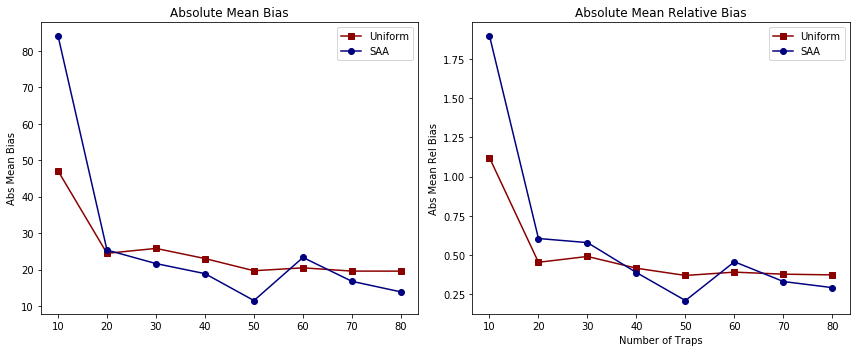

In [26]:
trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

# Use your working uniform path and pattern
uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA'

# Assuming SAA files as before
saa_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA1/TEST'


def compute_metrics(df):
    abs_diff = np.abs(df['N_mod'] - df['N_true'])
    mean_bias = abs_diff.mean()
    mean_rel_bias = (abs_diff / df['N_true']).mean()
    return mean_bias, mean_rel_bias


def process_uniform_data():
    mean_biases, mean_rel_biases = [], []
    for n_traps in trap_counts:
        fname = f'U_{n_traps}A_1km_SAA_151-300.csv'
        fpath = os.path.join(uniform_folder, fname)
        if not os.path.exists(fpath):
            mean_biases.append(np.nan)
            mean_rel_biases.append(np.nan)
            continue
        df = pd.read_csv(fpath)
        df_filtered = df[df['N_abs_error'] <= 1000]
        if len(df_filtered) == 0:
            mean_biases.append(np.nan)
            mean_rel_biases.append(np.nan)
            continue
        mb, mrb = compute_metrics(df_filtered)
        mean_biases.append(mb)
        mean_rel_biases.append(mrb)
    return np.array(mean_biases), np.array(mean_rel_biases)


def process_saa_data():
    mean_biases, mean_rel_biases = [], []
    for n_traps in trap_counts:
        pattern = os.path.join(saa_folder, f'SA1-*_{n_traps}traps_TEST_151-300.csv')
        files = glob.glob(pattern)
        bvals, rbvals = [], []
        for path in files:
            df = pd.read_csv(path)
            df_filtered = df[df['N_abs_error'] <= 1000]
            if len(df_filtered) == 0:
                continue
            mb, mrb = compute_metrics(df_filtered)
            bvals.append(mb)
            rbvals.append(mrb)
        mb_mean = np.nanmean(bvals) if bvals else np.nan
        mrb_mean = np.nanmean(rbvals) if rbvals else np.nan
        mean_biases.append(mb_mean)
        mean_rel_biases.append(mrb_mean)
    return np.array(mean_biases), np.array(mean_rel_biases)


uniform_biases, uniform_rel_biases = process_uniform_data()
saa_biases, saa_rel_biases = process_saa_data()

trap_counts_np = np.array(trap_counts)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex='col')
titles = ['Absolute Mean Bias', 'Absolute Mean Relative Bias']
ylabels = ['Abs Mean Bias', 'Abs Mean Rel Bias']

axs[0].plot(trap_counts_np, uniform_biases, marker='s', color='darkred', label='Uniform')
axs[0].plot(trap_counts_np, saa_biases, marker='o', color='navy', label='SAA')
axs[0].legend()
axs[0].set_title(titles[0])
axs[0].set_ylabel(ylabels[0])

axs[1].plot(trap_counts_np, uniform_rel_biases, marker='s', color='darkred', label='Uniform')
axs[1].plot(trap_counts_np, saa_rel_biases, marker='o', color='navy', label='SAA')
axs[1].legend()
axs[1].set_title(titles[1])
axs[1].set_ylabel(ylabels[1])

axs[-1].set_xlabel('Number of Traps')

plt.tight_layout()
plt.show()


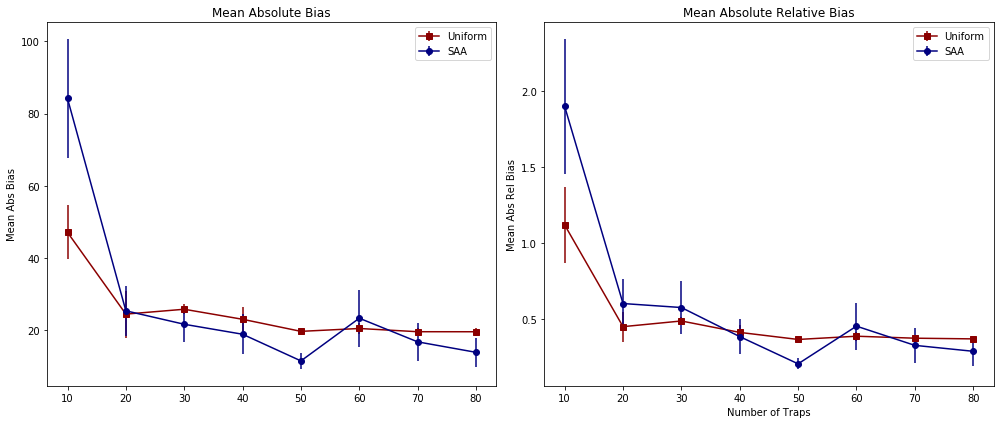

In [28]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


trap_counts = [10, 20, 30, 40, 50, 60, 70, 80]

uniform_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Uniform/1km_fullgrid_SAA'
saa_folder = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Sample Average Approximation/SA1/TEST'


def compute_metrics(df):
    abs_diff = np.abs(df['N_mod'] - df['N_true'])
    mean_bias = abs_diff.mean()
    mean_rel_bias = (abs_diff / df['N_true']).mean()
    se_bias = abs_diff.std(ddof=1) / np.sqrt(len(abs_diff))
    se_rel_bias = (abs_diff / df['N_true']).std(ddof=1) / np.sqrt(len(abs_diff))
    return mean_bias, mean_rel_bias, se_bias, se_rel_bias


def process_uniform_data():
    mean_biases, mean_rel_biases = [], []
    se_biases, se_rel_biases = [], []
    for n_traps in trap_counts:
        fname = f'U_{n_traps}A_1km_SAA_151-300.csv'
        fpath = os.path.join(uniform_folder, fname)
        if not os.path.exists(fpath):
            mean_biases.append(np.nan)
            se_biases.append(np.nan)
            mean_rel_biases.append(np.nan)
            se_rel_biases.append(np.nan)
            continue
        df = pd.read_csv(fpath)
        df_filtered = df[df['N_abs_error'] <= 1000]
        if len(df_filtered) == 0:
            mean_biases.append(np.nan)
            se_biases.append(np.nan)
            mean_rel_biases.append(np.nan)
            se_rel_biases.append(np.nan)
            continue
        mb, mrb, se, se_rel = compute_metrics(df_filtered)
        mean_biases.append(mb)
        se_biases.append(se)
        mean_rel_biases.append(mrb)
        se_rel_biases.append(se_rel)
    return (
        np.array(mean_biases), np.array(se_biases),
        np.array(mean_rel_biases), np.array(se_rel_biases)
    )


def process_saa_data():
    mean_biases, mean_rel_biases = [], []
    se_biases, se_rel_biases = [], []
    for n_traps in trap_counts:
        pattern = os.path.join(saa_folder, f'SA1-*_{n_traps}traps_TEST_151-300.csv')
        files = glob.glob(pattern)
        bvals, rbvals = [], []
        bvars, rbvars = [], []
        for path in files:
            df = pd.read_csv(path)
            df_filtered = df[df['N_abs_error'] <= 1000]
            if len(df_filtered) == 0:
                continue
            mb, mrb, se, se_rel = compute_metrics(df_filtered)
            bvals.append(mb)
            rbvals.append(mrb)
            bvars.append(se**2)      # variances for combining SE later
            rbvars.append(se_rel**2)
        if len(bvals) == 0:
            mean_biases.append(np.nan)
            se_biases.append(np.nan)
            mean_rel_biases.append(np.nan)
            se_rel_biases.append(np.nan)
            continue
        # Compute mean and combined SE using standard error of the mean of the means
        mb_mean = np.nanmean(bvals)
        mrb_mean = np.nanmean(rbvals)
        # SE of mean biases from folder-level means, using variance of means divided by number of files
        se_bias_combined = np.sqrt(np.nansum(bvars)) / len(bvars) if len(bvars) > 0 else np.nan
        se_rel_bias_combined = np.sqrt(np.nansum(rbvars)) / len(rbvars) if len(rbvars) > 0 else np.nan
        mean_biases.append(mb_mean)
        se_biases.append(se_bias_combined)
        mean_rel_biases.append(mrb_mean)
        se_rel_biases.append(se_rel_bias_combined)
    return (
        np.array(mean_biases), np.array(se_biases),
        np.array(mean_rel_biases), np.array(se_rel_biases)
    )


uniform_biases, uniform_se_biases, uniform_rel_biases, uniform_se_rel_biases = process_uniform_data()
saa_biases, saa_se_biases, saa_rel_biases, saa_se_rel_biases = process_saa_data()

trap_counts_np = np.array(trap_counts)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex='col')
titles = ['Mean Absolute Bias', 'Mean Absolute Relative Bias']
ylabels = ['Mean Abs Bias', 'Mean Abs Rel Bias']

axs[0].errorbar(trap_counts_np, uniform_biases, yerr=uniform_se_biases, fmt='s-', color='darkred', label='Uniform')
axs[0].errorbar(trap_counts_np, saa_biases, yerr=saa_se_biases, fmt='o-', color='navy', label='SAA')
axs[0].legend()
axs[0].set_title(titles[0])
axs[0].set_ylabel(ylabels[0])
axs[0].grid(False)

axs[1].errorbar(trap_counts_np, uniform_rel_biases, yerr=uniform_se_rel_biases, fmt='s-', color='darkred', label='Uniform')
axs[1].errorbar(trap_counts_np, saa_rel_biases, yerr=saa_se_rel_biases, fmt='o-', color='navy', label='SAA')
axs[1].legend()
axs[1].set_title(titles[1])
axs[1].set_ylabel(ylabels[1])
axs[1].grid(False)

axs[-1].set_xlabel('Number of Traps')

plt.tight_layout()
plt.show()


In [ ]:
# return a txt file that has for each row, the 